# Market Risk Analytics Platform

## Notebook 04 — VaR Backtesting and Stress Testing

### Objectives

This notebook evaluates the reliability of the rolling Value-at-Risk forecasts generated in Notebook 03 and assesses the portfolio's vulnerability to extreme market conditions.

It performs:

- identification of VaR exceptions;
- comparison of observed and expected exception rates;
- Kupiec unconditional coverage test;
- Christoffersen independence test;
- conditional coverage test;
- Basel traffic-light classification;
- historical stress testing;
- multi-day loss analysis;
- hypothetical scenario analysis;
- asset-level stress-loss attribution.

### Pipeline dependencies

This notebook depends on the successful execution of:

- Notebook 01 — Data Collection and Market Analysis;
- Notebook 02 — Portfolio Construction and P&L Analysis;
- Notebook 03 — Value-at-Risk and Expected Shortfall.

The outputs generated here will be used by:

- Notebook 05 — Risk Factors and Final Risk Reporting.

## Environnement du projet

### Monter Google Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


### Installer les bibliothèques

In [ ]:
!pip install -q scipy pyarrow openpyxl

### Définir les chemins

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/market-risk-analytics"
)

CONFIG_DIR = PROJECT_ROOT / "config"

DATA_PROCESSED_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures"
SRC_DIR = PROJECT_ROOT / "src"

for directory in [
    CONFIG_DIR,
    DATA_PROCESSED_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    SRC_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /content/drive/MyDrive/market-risk-analytics


### Importer les bibliothèques

In [ ]:
from datetime import datetime, timezone
import hashlib
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import chi2

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.6f}",
)

TRADING_DAYS_PER_YEAR = 252
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## Vérification des dépendances

### Définir les fichiers requis

In [ ]:
NOTEBOOK_03_REQUIRED_FILES = {
    "rolling_forecasts": (
        DATA_PROCESSED_DIR
        / "rolling_risk_forecasts.parquet"
    ),

    "static_risk_metrics": (
        DATA_PROCESSED_DIR
        / "static_risk_metrics.parquet"
    ),

    "portfolio_timeseries": (
        DATA_PROCESSED_DIR
        / "portfolio_timeseries.parquet"
    ),

    "portfolio_weights": (
        DATA_PROCESSED_DIR
        / "portfolio_weights.csv"
    ),

    "portfolio_positions": (
        DATA_PROCESSED_DIR
        / "portfolio_positions.csv"
    ),

    "asset_pnl": (
        DATA_PROCESSED_DIR
        / "asset_pnl_contributions.parquet"
    ),

    "manifest": (
        CONFIG_DIR
        / "notebook_03_manifest.json"
    ),
}

### Vérifier la présence des fichiers

In [ ]:
def validate_required_files(
    required_files: dict[str, Path],
) -> None:
    """Validate all upstream dependency files."""

    missing_files = [
        file_path
        for file_path in required_files.values()
        if not file_path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "Previous notebooks must be executed first. "
            f"Missing files: {missing_files}"
        )

    empty_files = [
        file_path
        for file_path in required_files.values()
        if file_path.stat().st_size == 0
    ]

    if empty_files:
        raise ValueError(
            "Empty dependency files detected: "
            f"{empty_files}"
        )

    print(
        "All Notebook 04 dependency files "
        "are available."
    )


validate_required_files(
    NOTEBOOK_03_REQUIRED_FILES
)

All Notebook 04 dependency files are available.


In [ ]:
print(f"Listing files in {DATA_PROCESSED_DIR}:")
!ls -l {DATA_PROCESSED_DIR}

Listing files in /content/drive/MyDrive/market-risk-analytics/data/processed:
total 6728
-rw------- 1 root root  139320 Jul 29 05:55 asset_pnl_contributions.parquet
-rw------- 1 root root  687557 Jul 28 22:35 final_dashboard_data.csv
-rw------- 1 root root  351158 Jul 28 22:35 final_dashboard_data.parquet
-rw------- 1 root root    4648 Jul 28 20:33 hypothetical_stress_results.parquet
-rw------- 1 root root  308517 Jul 29 05:53 market_log_returns.csv
-rw------- 1 root root  148269 Jul 29 05:53 market_log_returns.parquet
-rw------- 1 root root  268500 Jul 29 05:53 market_prices.csv
-rw------- 1 root root  113060 Jul 29 05:53 market_prices.parquet
-rw------- 1 root root  308541 Jul 29 05:53 market_returns.csv
-rw------- 1 root root  148269 Jul 29 05:53 market_returns.parquet
-rw------- 1 root root  151392 Jul 28 22:35 pca_scores.parquet
-rw------- 1 root root    1046 Jul 29 05:55 portfolio_positions.csv
-rw------- 1 root root  328896 Jul 29 05:55 portfolio_timeseries.csv
-rw------- 1 root

In [ ]:
print(f"Listing all files in {PROJECT_ROOT} recursively:")
!ls -lR {PROJECT_ROOT}

Listing all files in /content/drive/MyDrive/market-risk-analytics recursively:
/content/drive/MyDrive/market-risk-analytics:
total 24
drwx------ 2 root root 4096 Jul 23 07:23 config
drwx------ 4 root root 4096 Jul 23 07:23 data
drwx------ 2 root root 4096 Jul 23 07:23 figures
drwx------ 2 root root 4096 Jul 23 07:23 notebooks
drwx------ 2 root root 4096 Jul 23 07:23 reports
drwx------ 2 root root 4096 Jul 23 07:23 src

/content/drive/MyDrive/market-risk-analytics/config:
total 14
-rw------- 1 root root  432 Jul 29 05:53 asset_reference.csv
-rw------- 1 root root 2930 Jul 28 22:44 final_pipeline_manifest.json
-rw------- 1 root root  407 Jul 28 20:33 hypothetical_stress_scenarios.csv
-rw------- 1 root root 1828 Jul 29 05:55 notebook_02_manifest.json
-rw------- 1 root root 1974 Jul 29 05:57 notebook_03_manifest.json
-rw------- 1 root root 2905 Jul 28 20:33 notebook_04_manifest.json
-rw------- 1 root root 1642 Jul 29 05:53 pipeline_manifest.json
-rw------- 1 root root  122 Jul 29 05:57 stu

### Charger le manifeste du notebook 3

In [ ]:
with open(
    NOTEBOOK_03_REQUIRED_FILES["manifest"],
    "r",
    encoding="utf-8",
) as manifest_file:
    notebook_03_manifest = json.load(
        manifest_file
    )

if notebook_03_manifest.get("status") != "SUCCESS":
    raise RuntimeError(
        "Notebook 03 did not complete successfully."
    )

expected_producer = (
    "03_var_and_expected_shortfall.ipynb"
)

if (
    notebook_03_manifest.get("producer_notebook")
    != expected_producer
):
    raise RuntimeError(
        "Unexpected producer notebook "
        "in Notebook 03 manifest."
    )

print("Notebook 03 manifest validated.")

print(
    "Portfolio:",
    notebook_03_manifest["portfolio_name"],
)

print(
    "Primary confidence level:",
    notebook_03_manifest[
        "primary_confidence_level"
    ],
)

print(
    "Historical estimation window:",
    notebook_03_manifest[
        "historical_window"
    ],
)

Notebook 03 manifest validated.
Portfolio: Global Multi-Asset Risk Portfolio
Primary confidence level: 0.99
Historical estimation window: 250


### Fonction de calcul des empreintes

In [ ]:
def calculate_file_hash(
    file_path: Path,
) -> str:
    """Calculate the SHA-256 hash of a file."""

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(8192),
            b"",
        ):
            sha256.update(block)

    return sha256.hexdigest()

### Vérifier les empreintes disponibles

In [ ]:
expected_hashes = notebook_03_manifest.get(
    "file_hashes",
    {},
)

files_to_verify = {
    "rolling_risk_forecasts.parquet":
        NOTEBOOK_03_REQUIRED_FILES[
            "rolling_forecasts"
        ],

    "static_risk_metrics.parquet":
        NOTEBOOK_03_REQUIRED_FILES[
            "static_risk_metrics"
        ],

    "portfolio_timeseries.parquet":
        NOTEBOOK_03_REQUIRED_FILES[
            "portfolio_timeseries"
        ],

    "portfolio_weights.csv":
        NOTEBOOK_03_REQUIRED_FILES[
            "portfolio_weights"
        ],

    "portfolio_positions.csv":
        NOTEBOOK_03_REQUIRED_FILES[
            "portfolio_positions"
        ],
}

hash_validation_results = {}

for file_name, file_path in files_to_verify.items():

    calculated_hash = calculate_file_hash(
        file_path
    )

    expected_hash = expected_hashes.get(
        file_name
    )

    hash_validation_results[file_name] = {
        "expected_hash": expected_hash,
        "calculated_hash": calculated_hash,
        "is_valid": (
            calculated_hash == expected_hash
            if expected_hash is not None
            else None
        ),
    }

hash_validation_results

{'rolling_risk_forecasts.parquet': {'expected_hash': 'aa50c5589610db0f4635046115e0091297933278b5aec99df51cf5ed7bcf8213',
  'calculated_hash': 'aa50c5589610db0f4635046115e0091297933278b5aec99df51cf5ed7bcf8213',
  'is_valid': True},
 'static_risk_metrics.parquet': {'expected_hash': 'c0411358656a2313f68a323a2948e2084c0a321eed326040d77d8fe7e71bca41',
  'calculated_hash': 'c0411358656a2313f68a323a2948e2084c0a321eed326040d77d8fe7e71bca41',
  'is_valid': True},
 'portfolio_timeseries.parquet': {'expected_hash': '8ad5b57011be9abe8da80b2ac2a055acb3a344a7fd88ae806c42aa8252f2f5f1',
  'calculated_hash': '8ad5b57011be9abe8da80b2ac2a055acb3a344a7fd88ae806c42aa8252f2f5f1',
  'is_valid': True},
 'portfolio_weights.csv': {'expected_hash': '30770211096b759793962fb08d9985f0005e49940526f38bf1a86b5f187fdfd8',
  'calculated_hash': '30770211096b759793962fb08d9985f0005e49940526f38bf1a86b5f187fdfd8',
  'is_valid': True},
 'portfolio_positions.csv': {'expected_hash': '69b82696d83bef987a317995150b37f56c8319f8aa0

In [ ]:
invalid_hashes = [
    file_name
    for file_name, result
    in hash_validation_results.items()
    if result["is_valid"] is False
]

if invalid_hashes:
    raise RuntimeError(
        "The following upstream files were "
        "modified after generation: "
        f"{invalid_hashes}"
    )

print("Available file-integrity checks passed.")

Available file-integrity checks passed.


## Chargement des données

### Charger les fichiers

In [ ]:
rolling_risk_forecasts = pd.read_parquet(
    NOTEBOOK_03_REQUIRED_FILES[
        "rolling_forecasts"
    ]
)

static_risk_metrics = pd.read_parquet(
    NOTEBOOK_03_REQUIRED_FILES[
        "static_risk_metrics"
    ]
)

portfolio_timeseries = pd.read_parquet(
    NOTEBOOK_03_REQUIRED_FILES[
        "portfolio_timeseries"
    ]
)

portfolio_weights = pd.read_csv(
    NOTEBOOK_03_REQUIRED_FILES[
        "portfolio_weights"
    ],
    index_col=0,
).squeeze("columns")

portfolio_positions = pd.read_csv(
    NOTEBOOK_03_REQUIRED_FILES[
        "portfolio_positions"
    ],
    index_col=0,
)

asset_pnl_contributions = pd.read_parquet(
    NOTEBOOK_03_REQUIRED_FILES[
        "asset_pnl"
    ]
)

### Aperçu des données chargées

In [ ]:
print("rolling_risk_forecasts.head():")
display(rolling_risk_forecasts.head())
print("rolling_risk_forecasts.describe():")
display(rolling_risk_forecasts.describe())

rolling_risk_forecasts.head():


,historical_var_95,gaussian_var_95,ewma_var_95,historical_es_95,historical_var_99,gaussian_var_99,ewma_var_99,historical_es_99,portfolio_return,daily_pnl,portfolio_value_previous_day,historical_var_95_amount,gaussian_var_95_amount,ewma_var_95_amount,historical_es_95_amount,historical_var_99_amount,gaussian_var_99_amount,ewma_var_99_amount,historical_es_99_amount
date,,,,,,,,,,,,,,,,,,,
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003015,"3,014.507203","1,000,000.000000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004542,"4,555.998077","1,003,014.507203",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003795,"3,823.581379","1,007,570.505280",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000743,-751.024618,"1,011,394.086659",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001776,"-1,794.852431","1,010,643.062040",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


rolling_risk_forecasts.describe():


,historical_var_95,gaussian_var_95,ewma_var_95,historical_es_95,historical_var_99,gaussian_var_99,ewma_var_99,historical_es_99,portfolio_return,daily_pnl,portfolio_value_previous_day,historical_var_95_amount,gaussian_var_95_amount,ewma_var_95_amount,historical_es_95_amount,historical_var_99_amount,gaussian_var_99_amount,ewma_var_99_amount,historical_es_99_amount
count,"1,982.000000","1,982.000000","2,202.000000","1,982.000000","1,982.000000","1,982.000000","2,202.000000","1,982.000000","2,232.000000","2,232.000000","2,232.000000","1,982.000000","1,982.000000","2,202.000000","1,982.000000","1,982.000000","1,982.000000","2,202.000000","1,982.000000"
mean,0.009449,0.010025,0.009498,0.014398,0.017751,0.014329,0.013515,0.021586,0.000332,447.774491,"1,324,893.557938","12,909.769477","13,725.293381","12,739.105303","19,658.157147","24,174.789028","19,643.497365","18,138.604023","29,484.575490"
std,0.002421,0.003106,0.004744,0.005162,0.008252,0.004351,0.006709,0.010560,0.006544,"8,861.569190","291,866.452593","3,926.627543","4,788.708059","6,793.093833","7,412.789355","10,996.079828","6,844.743309","9,644.916744","14,329.114364"
min,0.004712,0.004589,0.003061,0.006724,0.008275,0.006738,0.004424,0.009376,-0.056249,"-58,860.168697","919,822.812277","5,339.972258","5,208.845873","3,445.625238","7,502.429530","9,082.538149","7,648.325736","4,979.099432","10,290.641645"
25%,0.007761,0.007680,0.006694,0.010438,0.012047,0.011064,0.009544,0.013862,-0.002627,"-3,469.132745","1,094,727.966751","10,373.977933","10,486.455661","8,171.342838","14,136.219787","16,173.376782","15,143.400242","11,639.775107","18,748.352246"
50%,0.008605,0.009167,0.008276,0.013612,0.014995,0.013261,0.011775,0.019189,0.000433,493.502573,"1,266,699.168958","12,912.659577","12,814.682300","11,276.056040","18,336.758029","21,093.935282","18,234.425571","16,074.486902","26,460.926405"
75%,0.011254,0.012247,0.010818,0.017015,0.019844,0.017444,0.015409,0.025176,0.003717,"4,622.008034","1,482,640.529964","15,723.427544","18,389.368233","15,464.191503","26,710.991183","34,024.324603","25,961.037742","22,001.817508","43,125.350202"
max,0.014835,0.015712,0.037720,0.026357,0.037405,0.022332,0.053360,0.045840,0.061093,"91,413.550184","2,051,897.642437","24,401.814746","22,601.503439","47,972.137151","33,512.488789","47,704.170644","32,696.215407","68,019.927699","58,461.443533"


In [ ]:
print("static_risk_metrics.head():")
display(static_risk_metrics.head())
print("static_risk_metrics.describe():")
display(static_risk_metrics.describe())

static_risk_metrics.head():


,model,confidence_level,var_return,var_amount,es_return,es_amount
0,Historical,0.950000,0.009685,"19,364.375208",0.015404,"30,799.643241"
1,Gaussian,0.950000,0.010432,"20,858.054779",0.013166,"26,325.423557"
2,Student-t,0.950000,0.009073,"18,141.389047",0.014691,"29,372.716000"
3,Monte Carlo Student-t,0.950000,0.009081,"18,157.339007",0.014508,"29,008.571879"
4,EWMA Gaussian,0.950000,0.010477,"20,947.094461",NaN,NaN


static_risk_metrics.describe():


,confidence_level,var_return,var_amount,es_return,es_amount
count,15.000000,15.000000,15.000000,12.000000,12.000000
mean,0.971667,0.012911,"25,814.050710",0.018662,"37,312.853884"
std,0.017078,0.002974,"5,946.075635",0.004661,"9,320.012997"
min,0.950000,0.009073,"18,141.389047",0.013166,"26,325.423557"
25%,0.950000,0.010454,"20,902.574620",0.014898,"29,786.753697"
50%,0.975000,0.012494,"24,981.033550",0.017844,"35,676.900088"
75%,0.990000,0.014923,"29,837.852653",0.020936,"41,859.358780"
max,0.990000,0.017864,"35,717.607647",0.026078,"52,141.525763"


In [ ]:
print("portfolio_timeseries.head():")
display(portfolio_timeseries.head())
print("portfolio_timeseries.describe():")
display(portfolio_timeseries.describe())

portfolio_timeseries.head():


,portfolio_value,portfolio_return,daily_pnl,cumulative_pnl,drawdown,rolling_20d_volatility,rolling_60d_volatility
date,,,,,,,
2018-01-02,"1,000,000.000000",NaN,NaN,0.000000,0.000000,NaN,NaN
2018-01-03,"1,003,014.507203",0.003015,"3,014.507203","3,014.507203",0.000000,NaN,NaN
2018-01-04,"1,007,570.505280",0.004542,"4,555.998077","7,570.505280",0.000000,NaN,NaN
2018-01-05,"1,011,394.086659",0.003795,"3,823.581379","11,394.086659",0.000000,NaN,NaN
2018-01-08,"1,010,643.062040",-0.000743,-751.024618,"10,643.062040",-0.000743,NaN,NaN


portfolio_timeseries.describe():


,portfolio_value,portfolio_return,daily_pnl,cumulative_pnl,drawdown,rolling_20d_volatility,rolling_60d_volatility
count,"2,233.000000","2,232.000000","2,232.000000","2,233.000000","2,233.000000","2,213.000000","2,173.000000"
mean,"1,325,195.635459",0.000332,447.774491,"325,195.635459",-0.038637,0.091336,0.094387
std,"292,150.001656",0.006544,"8,861.569190","292,150.001656",0.046408,0.050003,0.044047
min,"919,822.812277",-0.056249,"-58,860.168697","-80,177.187723",-0.221661,0.023932,0.032484
25%,"1,094,968.709744",-0.002627,"-3,469.132745","94,968.709744",-0.057782,0.061532,0.066622
50%,"1,266,760.916561",0.000433,493.502573,"266,760.916561",-0.019714,0.080641,0.081967
75%,"1,482,921.904539",0.003717,"4,622.008034","482,921.904539",-0.003965,0.104532,0.104460
max,"2,051,897.642437",0.061093,"91,413.550184","1,051,897.642437",0.000000,0.418635,0.273631


In [ ]:
print("portfolio_weights.head():")
display(portfolio_weights.head())
print("portfolio_weights.describe():")
display(portfolio_weights.describe())

portfolio_weights.head():


,target_weight
US_EQUITY,0.250000
EUROPE_EQUITY,0.200000
US_TREASURY,0.200000
CORPORATE_BOND,0.150000
GOLD,0.100000


portfolio_weights.describe():


,target_weight
count,6.000000
mean,0.166667
std,0.060553
min,0.100000
25%,0.112500
50%,0.175000
75%,0.200000
max,0.250000


In [ ]:
print("portfolio_positions.head():")
display(portfolio_positions.head())
print("portfolio_positions.describe():")
display(portfolio_positions.describe())

portfolio_positions.head():


,target_weight,initial_price,initial_allocation,units,ticker,description,risk_factor,currency,portfolio_name,reporting_currency
asset,,,,,,,,,,
US_EQUITY,0.250000,235.954285,"250,000.000000","1,059.527274",SPY,US equities — S&P 500 ETF,Equity,USD,Global Multi-Asset Risk Portfolio,EUR
EUROPE_EQUITY,0.200000,31.983484,"200,000.000000","6,253.227395",FEZ,European equities — Euro Stoxx 50 ETF,Equity,USD,Global Multi-Asset Risk Portfolio,EUR
US_TREASURY,0.200000,85.827789,"200,000.000000","2,330.247599",IEF,US government bonds — 7-10 year Treasury ETF,Interest Rate,USD,Global Multi-Asset Risk Portfolio,EUR
CORPORATE_BOND,0.150000,89.042908,"150,000.000000","1,684.581106",LQD,Investment-grade corporate bond ETF,Credit and Interest Rate,USD,Global Multi-Asset Risk Portfolio,EUR
GOLD,0.100000,125.150002,"100,000.000000",799.041141,GLD,Gold ETF,Commodity,USD,Global Multi-Asset Risk Portfolio,EUR


portfolio_positions.describe():


,target_weight,initial_price,initial_allocation,units
count,6.000000,6.000000,6.000000,6.000000
mean,0.166667,94.859938,"166,666.666667","15,896.603956"
std,0.060553,82.056000,"60,553.007082","33,057.469836"
min,0.100000,1.201158,"100,000.000000",799.041141
25%,0.112500,45.444561,"112,500.000000","1,215.790732"
50%,0.175000,87.435349,"175,000.000000","2,007.414353"
75%,0.200000,116.123228,"200,000.000000","5,272.482446"
max,0.250000,235.954285,"250,000.000000","83,252.999218"


In [ ]:
print("asset_pnl_contributions.head():")
display(asset_pnl_contributions.head())
print("asset_pnl_contributions.describe():")
display(asset_pnl_contributions.describe())

asset_pnl_contributions.head():


asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
date,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,"1,581.320529",782.571810,209.144842,273.279175,-263.685040,431.875886
2018-01-04,"1,060.351796","3,570.539791",-95.096545,-49.699975,511.385842,-441.482832
2018-01-05,"1,683.593624","2,054.297218",-247.083902,-49.674270,-103.873154,486.321863
2018-01-08,465.079057,-831.460930,-95.025432,-12.389650,-15.984237,-261.243427


asset_pnl_contributions.describe():


asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
count,"2,232.000000","2,232.000000","2,232.000000","2,232.000000","2,232.000000","2,232.000000"
mean,239.678029,101.437093,8.072563,13.424643,87.429132,-2.266968
std,"4,762.634074","3,197.095847",905.144168,924.324349,"2,422.589716",414.613948
min,"-32,828.499369","-20,347.165233","-6,013.447565","-7,916.909147","-40,711.131497","-2,532.571566"
25%,"-1,650.956284","-1,496.542010",-500.621354,-408.408614,-599.280856,-244.203007
50%,220.470786,146.715069,0.000000,15.005100,55.926540,-8.252247
75%,"2,583.567756","1,785.720143",515.479634,448.578583,783.056904,244.466007
max,"54,477.317554","26,123.941374","6,172.759613","10,569.322404","21,701.960312","2,545.671947"


### Normaliser les index

In [ ]:
time_series_objects = [
    rolling_risk_forecasts,
    portfolio_timeseries,
    asset_pnl_contributions,
]

for dataframe in time_series_objects:
    dataframe.index = pd.to_datetime(
        dataframe.index
    )

    dataframe.index.name = "date"

print(
    "Rolling forecasts:",
    rolling_risk_forecasts.shape,
)

print(
    "Portfolio time series:",
    portfolio_timeseries.shape,
)

print(
    "Asset P&L:",
    asset_pnl_contributions.shape,
)

Rolling forecasts: (2232, 19)
Portfolio time series: (2233, 7)
Asset P&L: (2233, 6)


## Extraire les séries principales

In [ ]:
portfolio_returns = (
    portfolio_timeseries[
        "portfolio_return"
    ]
    .astype(float)
)

portfolio_daily_pnl = (
    portfolio_timeseries[
        "daily_pnl"
    ]
    .astype(float)
)

portfolio_value = (
    portfolio_timeseries[
        "portfolio_value"
    ]
    .astype(float)
)

current_portfolio_value = float(
    portfolio_value.iloc[-1]
)

print(
    "Current portfolio value:",
    f"{current_portfolio_value:,.2f}",
)

Current portfolio value: 1,999,432.66


### Contrôler les données

In [ ]:
def validate_backtesting_inputs(
    forecasts: pd.DataFrame,
    portfolio_timeseries: pd.DataFrame,
) -> None:
    """Validate VaR backtesting and stress-testing inputs."""

    required_forecast_columns = {
        "daily_pnl",
        "portfolio_return",
        "historical_var_95_amount",
        "historical_var_99_amount",
        "gaussian_var_95_amount",
        "gaussian_var_99_amount",
        "ewma_var_95_amount",
        "ewma_var_99_amount",
    }

    missing_columns = (
        required_forecast_columns
        - set(forecasts.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing forecast columns: "
            f"{sorted(missing_columns)}"
        )

    if forecasts.empty:
        raise ValueError(
            "Rolling forecast dataset is empty."
        )

    if portfolio_timeseries.empty:
        raise ValueError(
            "Portfolio time series is empty."
        )

    print(
        "Backtesting and stress-testing "
        "inputs validated."
    )


validate_backtesting_inputs(
    forecasts=rolling_risk_forecasts,
    portfolio_timeseries=portfolio_timeseries,
)

Backtesting and stress-testing inputs validated.


## Convention du backtesting

## VaR backtesting convention

A VaR exception occurs when the observed daily loss exceeds the forecast Value-at-Risk.

Since daily P&L is positive for a gain and negative for a loss:

\[
Exception_t =
\mathbb{1}
\left(
P\&L_t < -VaR_t
\right)
\]

Equivalently, by defining the monetary loss as:

\[
Loss_t = -P\&L_t
\]

an exception occurs when:

\[
Loss_t > VaR_t
\]

For a 99% VaR, the expected probability of an exception is 1%.

For a 95% VaR, the expected probability of an exception is 5%.

## Construction du backtesting détaillé

### Définir les modèles

In [ ]:
BACKTEST_MODELS = {
    "Historical": {
        0.95: "historical_var_95_amount",
        0.99: "historical_var_99_amount",
    },

    "Gaussian": {
        0.95: "gaussian_var_95_amount",
        0.99: "gaussian_var_99_amount",
    },

    "EWMA Gaussian": {
        0.95: "ewma_var_95_amount",
        0.99: "ewma_var_99_amount",
    },
}

BACKTEST_MODELS

{'Historical': {0.95: 'historical_var_95_amount',
  0.99: 'historical_var_99_amount'},
 'Gaussian': {0.95: 'gaussian_var_95_amount', 0.99: 'gaussian_var_99_amount'},
 'EWMA Gaussian': {0.95: 'ewma_var_95_amount', 0.99: 'ewma_var_99_amount'}}

  ### Construire un format long

In [ ]:
backtest_records = []

for model_name, confidence_mapping in (
    BACKTEST_MODELS.items()
):

    for confidence_level, var_column in (
        confidence_mapping.items()
    ):

        model_data = (
            rolling_risk_forecasts[
                [
                    "daily_pnl",
                    "portfolio_return",
                    var_column,
                ]
            ]
            .dropna()
            .copy()
        )

        for date, row in model_data.iterrows():

            daily_pnl = float(
                row["daily_pnl"]
            )

            var_amount = float(
                row[var_column]
            )

            loss_amount = -daily_pnl

            exception = bool(
                daily_pnl < -var_amount
            )

            backtest_records.append({
                "date": date,
                "model": model_name,
                "confidence_level":
                    confidence_level,
                "expected_exception_rate":
                    1 - confidence_level,
                "daily_pnl":
                    daily_pnl,
                "loss_amount":
                    loss_amount,
                "var_amount":
                    var_amount,
                "portfolio_return":
                    float(
                        row["portfolio_return"]
                    ),
                "exception":
                    exception,
            })

var_backtest_detailed = pd.DataFrame(
    backtest_records
)

var_backtest_detailed["date"] = (
    pd.to_datetime(
        var_backtest_detailed["date"]
    )
)

var_backtest_detailed.head()

,date,model,confidence_level,expected_exception_rate,daily_pnl,loss_amount,var_amount,portfolio_return,exception
0,2018-12-19,Historical,0.950000,0.050000,"-4,783.042328","4,783.042328","7,234.582944",-0.005068,False
1,2018-12-20,Historical,0.950000,0.050000,"-3,822.240676","3,822.240676","7,197.917480",-0.004071,False
2,2018-12-21,Historical,0.950000,0.050000,"-6,890.404861","6,890.404861","7,168.617253",-0.007368,False
3,2018-12-24,Historical,0.950000,0.050000,"-8,439.267184","8,439.267184","7,115.797337",-0.009091,True
4,2018-12-25,Historical,0.950000,0.050000,259.139426,-259.139426,"7,157.325046",0.000282,False


### Ajouter la taille du dépassement

In [ ]:
var_backtest_detailed[
    "exception_amount"
] = np.where(
    var_backtest_detailed["exception"],
    (
        var_backtest_detailed["loss_amount"]
        - var_backtest_detailed["var_amount"]
    ),
    0.0,
)

var_backtest_detailed[
    "loss_var_ratio"
] = np.where(
    var_backtest_detailed["var_amount"] > 0,
    (
        var_backtest_detailed["loss_amount"]
        / var_backtest_detailed["var_amount"]
    ),
    np.nan,
)

var_backtest_detailed.head()

,date,model,confidence_level,expected_exception_rate,daily_pnl,loss_amount,var_amount,portfolio_return,exception,exception_amount,loss_var_ratio
0,2018-12-19,Historical,0.950000,0.050000,"-4,783.042328","4,783.042328","7,234.582944",-0.005068,False,0.000000,0.661136
1,2018-12-20,Historical,0.950000,0.050000,"-3,822.240676","3,822.240676","7,197.917480",-0.004071,False,0.000000,0.531020
2,2018-12-21,Historical,0.950000,0.050000,"-6,890.404861","6,890.404861","7,168.617253",-0.007368,False,0.000000,0.961190
3,2018-12-24,Historical,0.950000,0.050000,"-8,439.267184","8,439.267184","7,115.797337",-0.009091,True,"1,323.469847",1.185990
4,2018-12-25,Historical,0.950000,0.050000,259.139426,-259.139426,"7,157.325046",0.000282,False,0.000000,-0.036206


## Résumé des exceptions

### Résumé par modèle

In [ ]:
var_backtest_summary = (
    var_backtest_detailed
    .groupby(
        [
            "model",
            "confidence_level",
        ]
    )
    .agg(
        number_of_observations=(
            "exception",
            "size",
        ),
        number_of_exceptions=(
            "exception",
            "sum",
        ),
        observed_exception_rate=(
            "exception",
            "mean",
        ),
        expected_exception_rate=(
            "expected_exception_rate",
            "first",
        ),
        average_var_amount=(
            "var_amount",
            "mean",
        ),
        maximum_var_amount=(
            "var_amount",
            "max",
        ),
        average_exception_amount=(
            "exception_amount",
            lambda series: (
                series[series > 0].mean()
            ),
        ),
        maximum_loss_var_ratio=(
            "loss_var_ratio",
            "max",
        ),
    )
    .reset_index()
)

var_backtest_summary[
    "expected_number_of_exceptions"
] = (
    var_backtest_summary[
        "number_of_observations"
    ]
    * var_backtest_summary[
        "expected_exception_rate"
    ]
)

var_backtest_summary[
    "exception_rate_difference"
] = (
    var_backtest_summary[
        "observed_exception_rate"
    ]
    - var_backtest_summary[
        "expected_exception_rate"
    ]
)

var_backtest_summary

,model,confidence_level,number_of_observations,number_of_exceptions,observed_exception_rate,expected_exception_rate,average_var_amount,maximum_var_amount,average_exception_amount,maximum_loss_var_ratio,expected_number_of_exceptions,exception_rate_difference
0,EWMA Gaussian,0.950000,2202,130,0.059037,0.050000,"12,739.105303","47,972.137151","5,733.239625",3.928991,110.100000,0.009037
1,EWMA Gaussian,0.990000,2202,57,0.025886,0.010000,"18,138.604023","68,019.927699","5,675.464040",2.754400,22.020000,0.015886
2,Gaussian,0.950000,1982,106,0.053481,0.050000,"13,725.293381","22,601.503439","7,557.318120",7.096704,99.100000,0.003481
3,Gaussian,0.990000,1982,46,0.023209,0.010000,"19,643.497365","32,696.215407","9,023.300642",4.986181,19.820000,0.013209
4,Historical,0.950000,1982,113,0.057013,0.050000,"12,909.769477","24,401.814746","7,718.105560",9.204199,99.100000,0.007013
5,Historical,0.990000,1982,34,0.017154,0.010000,"24,174.789028","47,704.170644","8,252.868571",3.612112,19.820000,0.007154


## Visualisation des exceptions

### Fonction graphique

In [ ]:
def plot_var_backtest(
    detailed_backtest: pd.DataFrame,
    model_name: str,
    confidence_level: float,
) -> None:
    """Plot daily P&L and VaR threshold."""

    selected_data = (
        detailed_backtest[
            (
                detailed_backtest["model"]
                == model_name
            )
            & (
                detailed_backtest[
                    "confidence_level"
                ]
                == confidence_level
            )
        ]
        .sort_values("date")
    )

    if selected_data.empty:
        raise ValueError(
            "No backtesting observations "
            "for the selected model."
        )

    exceptions = selected_data[
        selected_data["exception"]
    ]

    plt.figure(figsize=(15, 7))

    plt.plot(
        selected_data["date"],
        selected_data["daily_pnl"],
        linewidth=1,
        label="Daily P&L",
    )

    plt.plot(
        selected_data["date"],
        -selected_data["var_amount"],
        linewidth=2,
        label=(
            f"{model_name} VaR "
            f"{confidence_level:.0%}"
        ),
    )

    plt.scatter(
        exceptions["date"],
        exceptions["daily_pnl"],
        marker="x",
        s=60,
        label="VaR exception",
    )

    plt.axhline(
        y=0,
        linewidth=1,
    )

    plt.title(
        f"{model_name} VaR Backtesting "
        f"at {confidence_level:.0%}"
    )

    plt.xlabel("Date")
    plt.ylabel("Amount")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Graphique historique 99 %

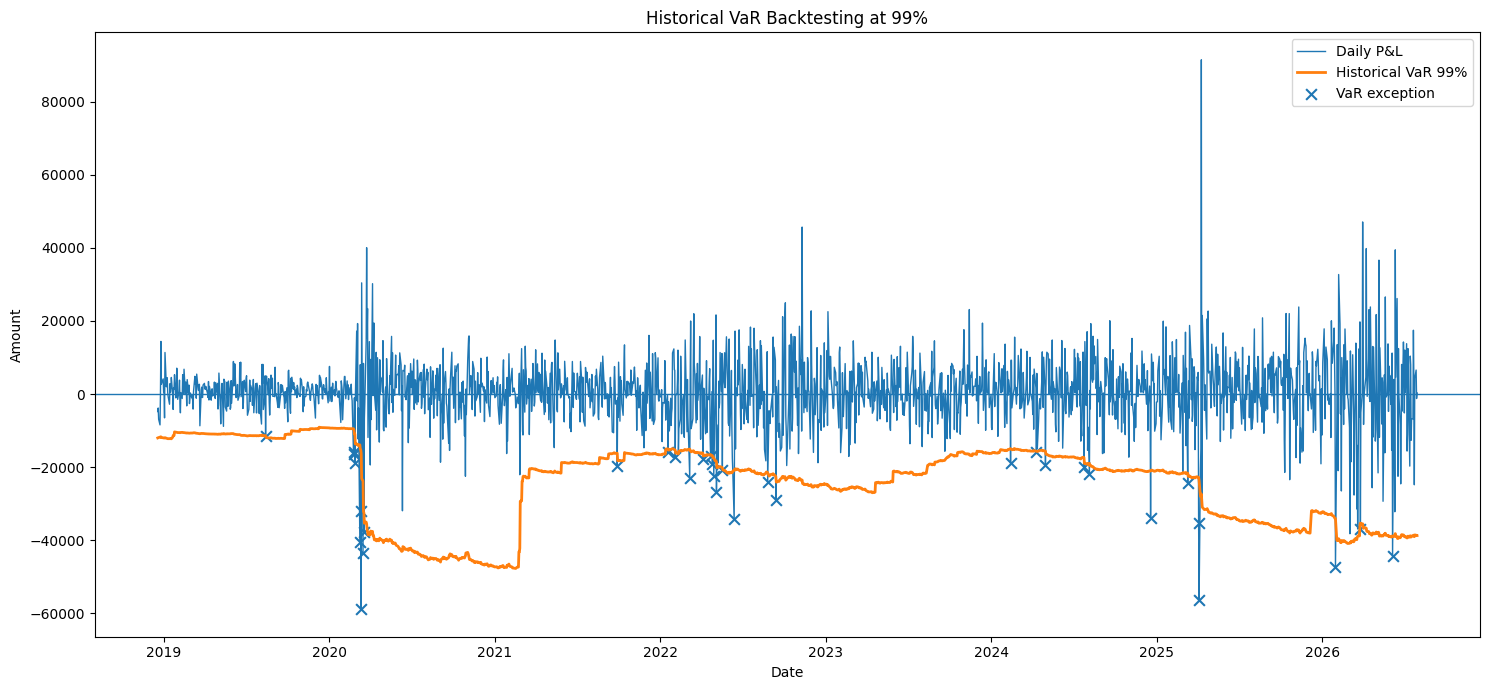

In [ ]:
plot_var_backtest(
    detailed_backtest=var_backtest_detailed,
    model_name="Historical",
    confidence_level=0.99,
)

### Graphique EWMA 99 %

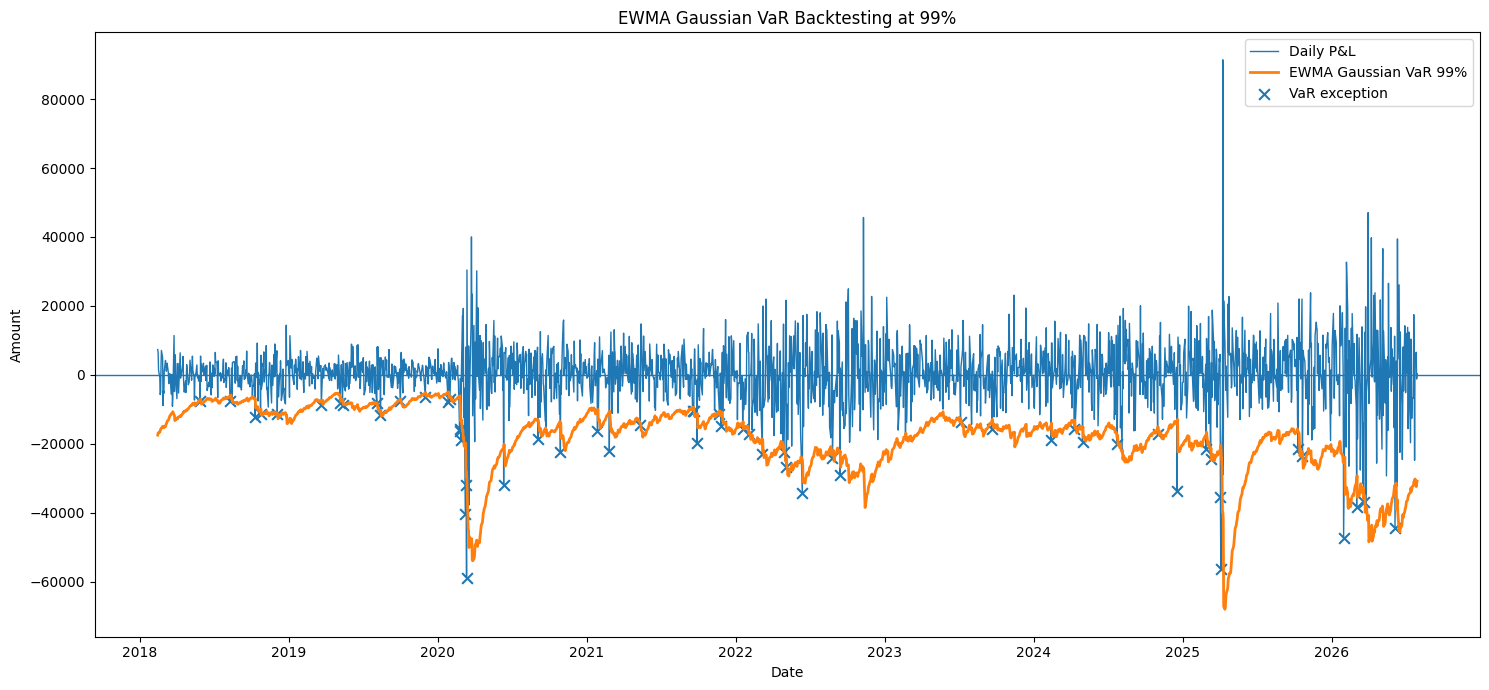

In [ ]:
plot_var_backtest(
    detailed_backtest=var_backtest_detailed,
    model_name="EWMA Gaussian",
    confidence_level=0.99,
)

## Test de Kupiec

Le test de Kupiec vérifie si la fréquence observée des exceptions correspond au niveau attendu.

### Log-vraisemblance de Bernoulli

In [ ]:
def bernoulli_log_likelihood(
    number_of_exceptions: int,
    number_of_observations: int,
    probability: float,
    epsilon: float = 1e-12,
) -> float:
    """Calculate a stable Bernoulli log-likelihood."""

    if number_of_observations <= 0:
        raise ValueError(
            "Number of observations must be positive."
        )

    if not 0 <= number_of_exceptions <= number_of_observations:
        raise ValueError(
            "Invalid number of exceptions."
        )

    clipped_probability = np.clip(
        probability,
        epsilon,
        1 - epsilon,
    )

    non_exceptions = (
        number_of_observations
        - number_of_exceptions
    )

    return float(
        number_of_exceptions
        * np.log(clipped_probability)
        + non_exceptions
        * np.log(
            1 - clipped_probability
        )
    )

### Fonction du test de Kupiec

In [ ]:
def kupiec_unconditional_coverage_test(
    exceptions: pd.Series,
    confidence_level: float,
    significance_level: float = 0.05,
) -> dict:
    """Perform Kupiec's unconditional coverage test."""

    exception_values = (
        pd.Series(exceptions)
        .dropna()
        .astype(int)
    )

    number_of_observations = len(
        exception_values
    )

    number_of_exceptions = int(
        exception_values.sum()
    )

    expected_probability = (
        1 - confidence_level
    )

    observed_probability = (
        number_of_exceptions
        / number_of_observations
    )

    null_log_likelihood = (
        bernoulli_log_likelihood(
            number_of_exceptions=
                number_of_exceptions,
            number_of_observations=
                number_of_observations,
            probability=
                expected_probability,
        )
    )

    alternative_log_likelihood = (
        bernoulli_log_likelihood(
            number_of_exceptions=
                number_of_exceptions,
            number_of_observations=
                number_of_observations,
            probability=
                observed_probability,
        )
    )

    likelihood_ratio = max(
        2
        * (
            alternative_log_likelihood
            - null_log_likelihood
        ),
        0.0,
    )

    p_value = float(
        chi2.sf(
            likelihood_ratio,
            df=1,
        )
    )

    reject_null = bool(
        p_value < significance_level
    )

    return {
        "test": "Kupiec UC",
        "number_of_observations":
            number_of_observations,
        "number_of_exceptions":
            number_of_exceptions,
        "expected_exception_rate":
            expected_probability,
        "observed_exception_rate":
            observed_probability,
        "likelihood_ratio":
            likelihood_ratio,
        "degrees_of_freedom":
            1,
        "p_value":
            p_value,
        "significance_level":
            significance_level,
        "reject_null":
            reject_null,
        "result": (
            "Reject"
            if reject_null
            else "Do not reject"
        ),
    }

## Test d’indépendance de Christoffersen

Ce test vérifie si les exceptions apparaissent indépendamment dans le temps.

Un bon modèle ne doit pas uniquement produire le bon nombre d’exceptions. Les exceptions ne doivent pas être excessivement regroupées.

### Compter les transitions

In [ ]:
def count_exception_transitions(
    exceptions: pd.Series,
) -> dict:
    """Count the four exception-state transitions."""

    values = (
        pd.Series(exceptions)
        .dropna()
        .astype(int)
        .to_numpy()
    )

    if len(values) < 2:
        raise ValueError(
            "At least two observations are required."
        )

    previous_values = values[:-1]
    current_values = values[1:]

    n00 = int(
        np.sum(
            (previous_values == 0)
            & (current_values == 0)
        )
    )

    n01 = int(
        np.sum(
            (previous_values == 0)
            & (current_values == 1)
        )
    )

    n10 = int(
        np.sum(
            (previous_values == 1)
            & (current_values == 0)
        )
    )

    n11 = int(
        np.sum(
            (previous_values == 1)
            & (current_values == 1)
        )
    )

    return {
        "n00": n00,
        "n01": n01,
        "n10": n10,
        "n11": n11,
    }

### Fonction du test d’indépendance

In [ ]:
def christoffersen_independence_test(
    exceptions: pd.Series,
    significance_level: float = 0.05,
    epsilon: float = 1e-12,
) -> dict:
    """Perform Christoffersen's independence test."""

    transitions = count_exception_transitions(
        exceptions
    )

    n00 = transitions["n00"]
    n01 = transitions["n01"]
    n10 = transitions["n10"]
    n11 = transitions["n11"]

    total_transitions = (
        n00 + n01 + n10 + n11
    )

    total_exceptions_after_transition = (
        n01 + n11
    )

    unconditional_probability = (
        total_exceptions_after_transition
        / total_transitions
        if total_transitions > 0
        else 0.0
    )

    probability_01 = (
        n01 / (n00 + n01)
        if (n00 + n01) > 0
        else 0.0
    )

    probability_11 = (
        n11 / (n10 + n11)
        if (n10 + n11) > 0
        else 0.0
    )

    unconditional_probability = np.clip(
        unconditional_probability,
        epsilon,
        1 - epsilon,
    )

    probability_01 = np.clip(
        probability_01,
        epsilon,
        1 - epsilon,
    )

    probability_11 = np.clip(
        probability_11,
        epsilon,
        1 - epsilon,
    )

    null_log_likelihood = (
        (n00 + n10)
        * np.log(
            1 - unconditional_probability
        )
        + (n01 + n11)
        * np.log(
            unconditional_probability
        )
    )

    alternative_log_likelihood = (
        n00
        * np.log(
            1 - probability_01
        )
        + n01
        * np.log(
            probability_01
        )
        + n10
        * np.log(
            1 - probability_11
        )
        + n11
        * np.log(
            probability_11
        )
    )

    likelihood_ratio = max(
        2
        * (
            alternative_log_likelihood
            - null_log_likelihood
        ),
        0.0,
    )

    p_value = float(
        chi2.sf(
            likelihood_ratio,
            df=1,
        )
    )

    reject_null = bool(
        p_value < significance_level
    )

    return {
        "test": "Christoffersen Independence",
        "n00": n00,
        "n01": n01,
        "n10": n10,
        "n11": n11,
        "probability_01":
            probability_01,
        "probability_11":
            probability_11,
        "likelihood_ratio":
            likelihood_ratio,
        "degrees_of_freedom":
            1,
        "p_value":
            p_value,
        "significance_level":
            significance_level,
        "reject_null":
            reject_null,
        "result": (
            "Reject"
            if reject_null
            else "Do not reject"
        ),
    }

## Test de couverture conditionnelle

Le test de couverture conditionnelle combine :

le test de fréquence de Kupiec ;

le test d’indépendance de Christoffersen.

### Fonction de couverture conditionnelle

In [ ]:
def conditional_coverage_test(
    exceptions: pd.Series,
    confidence_level: float,
    significance_level: float = 0.05,
) -> dict:
    """Perform Christoffersen conditional coverage test."""

    kupiec_result = (
        kupiec_unconditional_coverage_test(
            exceptions=exceptions,
            confidence_level=confidence_level,
            significance_level=
                significance_level,
        )
    )

    independence_result = (
        christoffersen_independence_test(
            exceptions=exceptions,
            significance_level=
                significance_level,
        )
    )

    likelihood_ratio = (
        kupiec_result["likelihood_ratio"]
        + independence_result[
            "likelihood_ratio"
        ]
    )

    p_value = float(
        chi2.sf(
            likelihood_ratio,
            df=2,
        )
    )

    reject_null = bool(
        p_value < significance_level
    )

    return {
        "test":
            "Christoffersen Conditional Coverage",
        "likelihood_ratio":
            likelihood_ratio,
        "degrees_of_freedom":
            2,
        "p_value":
            p_value,
        "significance_level":
            significance_level,
        "reject_null":
            reject_null,
        "result": (
            "Reject"
            if reject_null
            else "Do not reject"
        ),
    }

## Appliquer les tests statistiques

### Calculer les résultats

In [ ]:
SIGNIFICANCE_LEVEL = 0.05

statistical_backtest_records = []

for (
    model_name,
    confidence_level
), group_data in var_backtest_detailed.groupby(
    [
        "model",
        "confidence_level",
    ]
):

    exceptions = (
        group_data
        .sort_values("date")[
            "exception"
        ]
    )

    kupiec_result = (
        kupiec_unconditional_coverage_test(
            exceptions=exceptions,
            confidence_level=confidence_level,
            significance_level=
                SIGNIFICANCE_LEVEL,
        )
    )

    independence_result = (
        christoffersen_independence_test(
            exceptions=exceptions,
            significance_level=
                SIGNIFICANCE_LEVEL,
        )
    )

    conditional_result = (
        conditional_coverage_test(
            exceptions=exceptions,
            confidence_level=confidence_level,
            significance_level=
                SIGNIFICANCE_LEVEL,
        )
    )

    statistical_backtest_records.append({
        "model": model_name,
        "confidence_level":
            confidence_level,

        "number_of_observations":
            kupiec_result[
                "number_of_observations"
            ],

        "number_of_exceptions":
            kupiec_result[
                "number_of_exceptions"
            ],

        "expected_exception_rate":
            kupiec_result[
                "expected_exception_rate"
            ],

        "observed_exception_rate":
            kupiec_result[
                "observed_exception_rate"
            ],

        "kupiec_lr":
            kupiec_result[
                "likelihood_ratio"
            ],

        "kupiec_p_value":
            kupiec_result["p_value"],

        "kupiec_result":
            kupiec_result["result"],

        "independence_lr":
            independence_result[
                "likelihood_ratio"
            ],

        "independence_p_value":
            independence_result[
                "p_value"
            ],

        "independence_result":
            independence_result[
                "result"
            ],

        "conditional_coverage_lr":
            conditional_result[
                "likelihood_ratio"
            ],

        "conditional_coverage_p_value":
            conditional_result[
                "p_value"
            ],

        "conditional_coverage_result":
            conditional_result[
                "result"
            ],

        "n00":
            independence_result["n00"],

        "n01":
            independence_result["n01"],

        "n10":
            independence_result["n10"],

        "n11":
            independence_result["n11"],
    })

statistical_backtest_results = pd.DataFrame(
    statistical_backtest_records
)

statistical_backtest_results

,model,confidence_level,number_of_observations,number_of_exceptions,expected_exception_rate,observed_exception_rate,kupiec_lr,kupiec_p_value,kupiec_result,independence_lr,independence_p_value,independence_result,conditional_coverage_lr,conditional_coverage_p_value,conditional_coverage_result,n00,n01,n10,n11
0,EWMA Gaussian,0.950000,2202,130,0.050000,0.059037,3.587715,0.058208,Do not reject,0.731780,0.392307,Do not reject,4.319496,0.115354,Do not reject,1951,120,120,10
1,EWMA Gaussian,0.990000,2202,57,0.010000,0.025886,39.029732,0.000000,Reject,3.163217,0.075315,Do not reject,42.192949,0.000000,Reject,2091,53,53,4
2,Gaussian,0.950000,1982,106,0.050000,0.053481,0.494963,0.481722,Do not reject,6.167172,0.013014,Reject,6.662135,0.035755,Reject,1781,94,94,12
3,Gaussian,0.990000,1982,46,0.010000,0.023209,25.450253,0.000000,Reject,5.095007,0.023995,Reject,30.545260,0.000000,Reject,1893,42,42,4
4,Historical,0.950000,1982,113,0.050000,0.057013,1.967260,0.160739,Do not reject,4.414055,0.035644,Reject,6.381315,0.041145,Reject,1767,101,101,12
5,Historical,0.990000,1982,34,0.010000,0.017154,8.440213,0.003670,Reject,5.351854,0.020700,Reject,13.792067,0.001012,Reject,1916,31,31,3


### Ajouter une décision synthétique

In [ ]:
statistical_backtest_results[
    "overall_model_assessment"
] = np.where(
    (
        statistical_backtest_results[
            "kupiec_result"
        ]
        == "Do not reject"
    )
    & (
        statistical_backtest_results[
            "independence_result"
        ]
        == "Do not reject"
    )
    & (
        statistical_backtest_results[
            "conditional_coverage_result"
        ]
        == "Do not reject"
    ),
    "Acceptable",
    "Requires review",
)

statistical_backtest_results

,model,confidence_level,number_of_observations,number_of_exceptions,expected_exception_rate,observed_exception_rate,kupiec_lr,kupiec_p_value,kupiec_result,independence_lr,independence_p_value,independence_result,conditional_coverage_lr,conditional_coverage_p_value,conditional_coverage_result,n00,n01,n10,n11,overall_model_assessment
0,EWMA Gaussian,0.950000,2202,130,0.050000,0.059037,3.587715,0.058208,Do not reject,0.731780,0.392307,Do not reject,4.319496,0.115354,Do not reject,1951,120,120,10,Acceptable
1,EWMA Gaussian,0.990000,2202,57,0.010000,0.025886,39.029732,0.000000,Reject,3.163217,0.075315,Do not reject,42.192949,0.000000,Reject,2091,53,53,4,Requires review
2,Gaussian,0.950000,1982,106,0.050000,0.053481,0.494963,0.481722,Do not reject,6.167172,0.013014,Reject,6.662135,0.035755,Reject,1781,94,94,12,Requires review
3,Gaussian,0.990000,1982,46,0.010000,0.023209,25.450253,0.000000,Reject,5.095007,0.023995,Reject,30.545260,0.000000,Reject,1893,42,42,4,Requires review
4,Historical,0.950000,1982,113,0.050000,0.057013,1.967260,0.160739,Do not reject,4.414055,0.035644,Reject,6.381315,0.041145,Reject,1767,101,101,12,Requires review
5,Historical,0.990000,1982,34,0.010000,0.017154,8.440213,0.003670,Reject,5.351854,0.020700,Reject,13.792067,0.001012,Reject,1916,31,31,3,Requires review


## 13. Basel Traffic Light

Le classement est appliqué à une VaR de 99 % sur les 250 dernières observations disponibles.

- Green zone: 0 to 4 exceptions

- Yellow zone: 5 to 9 exceptions

- Red zone: 10 or more exceptions

### Fonction Basel

In [ ]:
def basel_traffic_light(
    exceptions: pd.Series,
    test_window: int = 250,
) -> dict:
    """Classify the last 250 VaR observations."""

    clean_exceptions = (
        pd.Series(exceptions)
        .dropna()
        .astype(int)
    )

    if len(clean_exceptions) < test_window:
        analysis_sample = (
            clean_exceptions.copy()
        )

        complete_window = False

    else:
        analysis_sample = (
            clean_exceptions.iloc[
                -test_window:
            ]
        )

        complete_window = True

    exception_count = int(
        analysis_sample.sum()
    )

    if exception_count <= 4:
        zone = "Green"

    elif exception_count <= 9:
        zone = "Yellow"

    else:
        zone = "Red"

    return {
        "test_window":
            test_window,
        "available_observations":
            len(analysis_sample),
        "complete_250_day_window":
            complete_window,
        "number_of_exceptions":
            exception_count,
        "traffic_light_zone":
            zone,
    }

### Appliquer le classement

## Validation du backtesting

### Contrôles de cohérence

In [ ]:
def validate_backtesting_outputs(
    detailed_backtest: pd.DataFrame,
    summary: pd.DataFrame,
    statistical_results: pd.DataFrame,
) -> None:
    """Validate the complete backtesting outputs."""

    if detailed_backtest.empty:
        raise ValueError(
            "Detailed backtesting data is empty."
        )

    if summary.empty:
        raise ValueError(
            "Backtesting summary is empty."
        )

    if statistical_results.empty:
        raise ValueError(
            "Statistical test results are empty."
        )

    if detailed_backtest[
        "var_amount"
    ].lt(0).any():
        raise ValueError(
            "Negative VaR amounts detected."
        )

    exception_validation = (
        detailed_backtest[
            "daily_pnl"
        ]
        < -detailed_backtest[
            "var_amount"
        ]
    )

    if not (
        exception_validation
        == detailed_backtest[
            "exception"
        ]
    ).all():
        raise ValueError(
            "Exception indicator is inconsistent."
        )

    probability_columns = [
        "expected_exception_rate",
        "observed_exception_rate",
    ]

    for column in probability_columns:

        if not summary[column].between(
            0,
            1,
        ).all():
            raise ValueError(
                f"Invalid probabilities in {column}."
            )

    p_value_columns = [
        "kupiec_p_value",
        "independence_p_value",
        "conditional_coverage_p_value",
    ]

    for column in p_value_columns:

        if not statistical_results[
            column
        ].between(
            0,
            1,
        ).all():
            raise ValueError(
                f"Invalid p-values in {column}."
            )

    print("Backtesting output validation successful.")


validate_backtesting_outputs(
    detailed_backtest=var_backtest_detailed,
    summary=var_backtest_summary,
    statistical_results=
        statistical_backtest_results,
)

Backtesting output validation successful.


## Analyse des dates d’exception

### Extraire les exceptions à 99 %

In [ ]:
var_exceptions_99 = (
    var_backtest_detailed[
        (
            var_backtest_detailed[
                "confidence_level"
            ]
            == 0.99
        )
        & (
            var_backtest_detailed[
                "exception"
            ]
        )
    ]
    .sort_values(
        [
            "date",
            "model",
        ]
    )
)

var_exceptions_99.head(20)

,date,model,confidence_level,expected_exception_rate,daily_pnl,loss_amount,var_amount,portfolio_return,exception,exception_amount,loss_var_ratio
10204,2018-05-29,EWMA Gaussian,0.990000,0.010000,"-7,689.188548","7,689.188548","7,234.406108",-0.007782,True,454.782440,1.062864
10257,2018-08-10,EWMA Gaussian,0.990000,0.010000,"-7,480.407047","7,480.407047","6,028.855374",-0.007526,True,"1,451.551673",1.240767
10300,2018-10-10,EWMA Gaussian,0.990000,0.010000,"-12,306.494817","12,306.494817","7,009.950689",-0.012556,True,"5,296.544129",1.755575
10310,2018-10-24,EWMA Gaussian,0.990000,0.010000,"-11,271.607920","11,271.607920","10,274.373514",-0.011722,True,997.234406,1.097060
10339,2018-12-04,EWMA Gaussian,0.990000,0.010000,"-11,483.391820","11,483.391820","11,016.709338",-0.011843,True,466.682482,1.042361
10417,2019-03-22,EWMA Gaussian,0.990000,0.010000,"-8,675.008215","8,675.008215","7,439.371969",-0.008570,True,"1,235.636246",1.166094
10449,2019-05-07,EWMA Gaussian,0.990000,0.010000,"-8,154.252784","8,154.252784","6,507.462853",-0.007968,True,"1,646.789931",1.253062
10453,2019-05-13,EWMA Gaussian,0.990000,0.010000,"-8,842.200185","8,842.200185","7,247.398199",-0.008693,True,"1,594.801986",1.220052
10513,2019-08-05,EWMA Gaussian,0.990000,0.010000,"-8,205.026682","8,205.026682","8,158.207637",-0.007793,True,46.819045,1.005739
10520,2019-08-14,EWMA Gaussian,0.990000,0.010000,"-11,550.960480","11,550.960480","10,334.261694",-0.010864,True,"1,216.698786",1.117734


### Fréquence annuelle des exceptions

In [ ]:
annual_exception_counts = (
    var_exceptions_99
    .assign(
        year=lambda data: (
            data["date"].dt.year
        )
    )
    .groupby(
        [
            "model",
            "year",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

annual_exception_counts

year,2018,2019,2020,2021,2022,2023,2024,2025,2026
model,,,,,,,,,
EWMA Gaussian,5,7,11,8,8,2,6,6,4
Gaussian,0,1,11,2,15,0,5,5,7
Historical,0,1,8,1,12,0,6,3,3


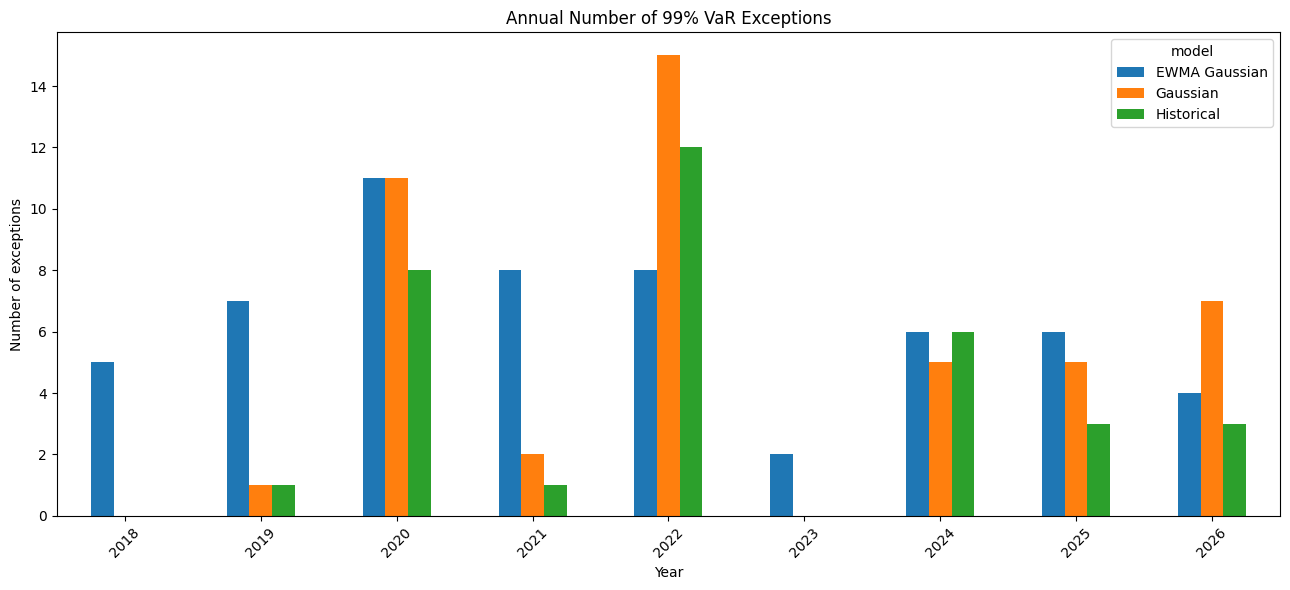

In [ ]:
annual_exception_counts.T.plot(
    kind="bar",
    figsize=(13, 6),
    title="Annual Number of 99% VaR Exceptions",
)

plt.xlabel("Year")
plt.ylabel("Number of exceptions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Stress tests historiques

Nous allons mesurer le comportement réel du portefeuille durant plusieurs périodes de tension.

### Définir les périodes historiques

In [ ]:
HISTORICAL_STRESS_PERIODS = {
    "COVID-19 Market Shock": {
        "start_date": "2020-02-19",
        "end_date": "2020-03-23",
    },

    "COVID-19 Extended Volatility": {
        "start_date": "2020-02-19",
        "end_date": "2020-06-30",
    },

    "2022 Inflation and Rate Shock": {
        "start_date": "2022-01-03",
        "end_date": "2022-10-12",
    },

    "2023 Banking Stress": {
        "start_date": "2023-03-01",
        "end_date": "2023-03-31",
    },
}

### Fonction de stress historique

In [ ]:
def calculate_historical_stress_period(
    portfolio_data: pd.DataFrame,
    scenario_name: str,
    start_date: str,
    end_date: str,
) -> dict:
    """Calculate portfolio risk metrics over a historical period."""

    start_timestamp = pd.Timestamp(
        start_date
    )

    end_timestamp = pd.Timestamp(
        end_date
    )

    scenario_data = portfolio_data.loc[
        (
            portfolio_data.index
            >= start_timestamp
        )
        & (
            portfolio_data.index
            <= end_timestamp
        )
    ].copy()

    if len(scenario_data) < 2:
        return {
            "scenario":
                scenario_name,
            "requested_start_date":
                start_date,
            "requested_end_date":
                end_date,
            "status":
                "Insufficient data",
        }

    scenario_returns = (
        scenario_data[
            "portfolio_return"
        ]
        .dropna()
    )

    scenario_values = (
        scenario_data[
            "portfolio_value"
        ]
        .dropna()
    )

    scenario_pnl = (
        scenario_data[
            "daily_pnl"
        ]
        .dropna()
    )

    initial_value = float(
        scenario_values.iloc[0]
    )

    final_value = float(
        scenario_values.iloc[-1]
    )

    total_return = (
        final_value
        / initial_value
        - 1
    )

    total_pnl = (
        final_value
        - initial_value
    )

    running_maximum = (
        scenario_values.cummax()
    )

    drawdowns = (
        scenario_values
        / running_maximum
        - 1
    )

    return {
        "scenario":
            scenario_name,

        "requested_start_date":
            start_date,

        "requested_end_date":
            end_date,

        "actual_start_date":
            str(
                scenario_data.index
                .min()
                .date()
            ),

        "actual_end_date":
            str(
                scenario_data.index
                .max()
                .date()
            ),

        "number_of_observations":
            len(scenario_data),

        "initial_value":
            initial_value,

        "final_value":
            final_value,

        "total_return":
            total_return,

        "total_pnl":
            total_pnl,

        "worst_daily_return":
            float(
                scenario_returns.min()
            ),

        "worst_daily_pnl":
            float(
                scenario_pnl.min()
            ),

        "annualized_volatility":
            float(
                scenario_returns.std(
                    ddof=1
                )
                * np.sqrt(
                    TRADING_DAYS_PER_YEAR
                )
            ),

        "maximum_drawdown":
            float(
                drawdowns.min()
            ),

        "maximum_drawdown_date":
            str(
                drawdowns.idxmin().date()
            ),

        "status":
            "SUCCESS",
    }

### Calculer les scénarios historiques

In [ ]:
historical_stress_records = []

for scenario_name, scenario_parameters in (
    HISTORICAL_STRESS_PERIODS.items()
):

    historical_stress_records.append(
        calculate_historical_stress_period(
            portfolio_data=
                portfolio_timeseries,
            scenario_name=
                scenario_name,
            start_date=
                scenario_parameters[
                    "start_date"
                ],
            end_date=
                scenario_parameters[
                    "end_date"
                ],
        )
    )

historical_stress_results = pd.DataFrame(
    historical_stress_records
)

historical_stress_results

,scenario,requested_start_date,requested_end_date,actual_start_date,actual_end_date,number_of_observations,initial_value,final_value,total_return,total_pnl,worst_daily_return,worst_daily_pnl,annualized_volatility,maximum_drawdown,maximum_drawdown_date,status
0,COVID-19 Market Shock,2020-02-19,2020-03-23,2020-02-19,2020-03-23,24,"1,148,457.225196","950,366.889268",-0.172484,"-198,090.335929",-0.056249,"-58,860.168697",0.332069,-0.185107,2020-03-20,SUCCESS
1,COVID-19 Extended Volatility,2020-02-19,2020-06-30,2020-02-19,2020-06-30,95,"1,148,457.225196","1,139,748.586652",-0.007583,"-8,708.638544",-0.056249,"-58,860.168697",0.228806,-0.185107,2020-03-20,SUCCESS
2,2022 Inflation and Rate Shock,2022-01-03,2022-10-12,2022-01-03,2022-10-12,203,"1,376,339.371999","1,078,324.050067",-0.216527,"-298,015.321932",-0.028977,"-34,244.324790",0.139456,-0.218034,2022-09-27,SUCCESS
3,2023 Banking Stress,2023-03-01,2023-03-31,2023-03-01,2023-03-31,23,"1,216,174.881534","1,272,054.496673",0.045947,"55,879.615139",-0.010876,"-13,420.951935",0.084725,-0.017496,2023-03-09,SUCCESS


### Pires pertes sur plusieurs horizons

Le portefeuille peut subir une perte progressive sur plusieurs jours même si aucune journée individuelle ne semble extrême.

Nous allons analyser les horizons :

1 jour
5 jours
10 jours
20 jours

### Fonction de rendement glissant composé

In [ ]:
def calculate_rolling_horizon_returns(
    returns: pd.Series,
    horizon_days: int,
) -> pd.Series:
    """Calculate compounded rolling returns."""

    if horizon_days <= 0:
        raise ValueError(
            "Horizon must be positive."
        )

    rolling_returns = (
        (1 + returns)
        .rolling(
            window=horizon_days,
            min_periods=horizon_days,
        )
        .apply(
            np.prod,
            raw=True,
        )
        - 1
    )

    rolling_returns.name = (
        f"rolling_{horizon_days}d_return"
    )

    return rolling_returns

### Identifier les pires périodes

In [ ]:
STRESS_HORIZONS = [
    1,
    5,
    10,
    20,
]

rolling_horizon_stress_records = []

for horizon_days in STRESS_HORIZONS:

    horizon_returns = (
        calculate_rolling_horizon_returns(
            returns=portfolio_returns,
            horizon_days=horizon_days,
        )
    )

    valid_returns = (
        horizon_returns.dropna()
    )

    worst_end_date = (
        valid_returns.idxmin()
    )

    worst_return = float(
        valid_returns.min()
    )

    worst_start_position = max(
        portfolio_returns.index.get_loc(
            worst_end_date
        )
        - horizon_days
        + 1,
        0,
    )

    worst_start_date = (
        portfolio_returns.index[
            worst_start_position
        ]
    )

    approximate_loss_amount = (
        -worst_return
        * current_portfolio_value
    )

    rolling_horizon_stress_records.append({
        "horizon_days":
            horizon_days,

        "worst_start_date":
            str(
                worst_start_date.date()
            ),

        "worst_end_date":
            str(
                worst_end_date.date()
            ),

        "worst_compounded_return":
            worst_return,

        "loss_amount_at_current_value":
            approximate_loss_amount,
    })

rolling_horizon_stress_results = pd.DataFrame(
    rolling_horizon_stress_records
)

rolling_horizon_stress_results

,horizon_days,worst_start_date,worst_end_date,worst_compounded_return,loss_amount_at_current_value
0,1,2020-03-12,2020-03-12,-0.056249,"112,466.485235"
1,5,2020-03-06,2020-03-12,-0.113967,"227,868.347991"
2,10,2020-03-05,2020-03-18,-0.161423,"322,754.914502"
3,20,2020-02-24,2020-03-20,-0.183320,"366,536.793009"


### Visualiser les pertes par horizon

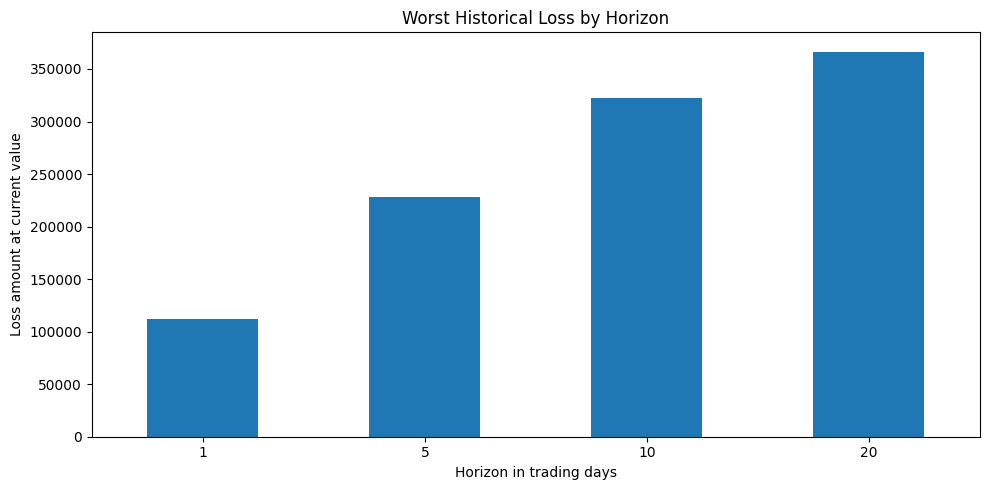

In [ ]:
rolling_horizon_stress_results.set_index(
    "horizon_days"
)[
    "loss_amount_at_current_value"
].plot(
    kind="bar",
    figsize=(10, 5),
    title="Worst Historical Loss by Horizon",
)

plt.xlabel("Horizon in trading days")
plt.ylabel("Loss amount at current value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Stress tests hypothétiques

Les scénarios appliquent un choc direct à chaque facteur de marché.

Les chocs représentent des variations instantanées des instruments utilisés comme proxies.

### Définir les scénarios

In [ ]:
HYPOTHETICAL_STRESS_SCENARIOS = pd.DataFrame(
    {
        "Global Equity Selloff": {
            "US_EQUITY": -0.20,
            "EUROPE_EQUITY": -0.25,
            "US_TREASURY": 0.04,
            "CORPORATE_BOND": -0.08,
            "GOLD": 0.06,
            "EURUSD": -0.04,
        },

        "Severe Global Crisis": {
            "US_EQUITY": -0.35,
            "EUROPE_EQUITY": -0.40,
            "US_TREASURY": -0.03,
            "CORPORATE_BOND": -0.18,
            "GOLD": 0.10,
            "EURUSD": -0.10,
        },

        "Interest Rate Shock": {
            "US_EQUITY": -0.10,
            "EUROPE_EQUITY": -0.12,
            "US_TREASURY": -0.10,
            "CORPORATE_BOND": -0.12,
            "GOLD": -0.06,
            "EURUSD": -0.05,
        },

        "Credit Spread Widening": {
            "US_EQUITY": -0.08,
            "EUROPE_EQUITY": -0.10,
            "US_TREASURY": 0.02,
            "CORPORATE_BOND": -0.15,
            "GOLD": 0.03,
            "EURUSD": -0.02,
        },

        "USD Appreciation Shock": {
            "US_EQUITY": -0.05,
            "EUROPE_EQUITY": -0.08,
            "US_TREASURY": 0.01,
            "CORPORATE_BOND": -0.03,
            "GOLD": -0.08,
            "EURUSD": -0.12,
        },

        "Commodity Safe-Haven Rally": {
            "US_EQUITY": -0.15,
            "EUROPE_EQUITY": -0.18,
            "US_TREASURY": 0.05,
            "CORPORATE_BOND": -0.05,
            "GOLD": 0.20,
            "EURUSD": 0.03,
        },
    }
).T

HYPOTHETICAL_STRESS_SCENARIOS.index.name = (
    "scenario"
)

HYPOTHETICAL_STRESS_SCENARIOS

,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
scenario,,,,,,
Global Equity Selloff,-0.200000,-0.250000,0.040000,-0.080000,0.060000,-0.040000
Severe Global Crisis,-0.350000,-0.400000,-0.030000,-0.180000,0.100000,-0.100000
Interest Rate Shock,-0.100000,-0.120000,-0.100000,-0.120000,-0.060000,-0.050000
Credit Spread Widening,-0.080000,-0.100000,0.020000,-0.150000,0.030000,-0.020000
USD Appreciation Shock,-0.050000,-0.080000,0.010000,-0.030000,-0.080000,-0.120000
Commodity Safe-Haven Rally,-0.150000,-0.180000,0.050000,-0.050000,0.200000,0.030000


### Vérifier les scénarios

In [ ]:
def validate_stress_scenarios(
    scenarios: pd.DataFrame,
    portfolio_assets: list[str],
) -> None:
    """Validate hypothetical stress scenarios."""

    if scenarios.empty:
        raise ValueError(
            "Stress scenario table is empty."
        )

    missing_assets = (
        set(portfolio_assets)
        - set(scenarios.columns)
    )

    if missing_assets:
        raise ValueError(
            "Stress scenarios are missing assets: "
            f"{sorted(missing_assets)}"
        )

    selected_scenarios = scenarios[
        portfolio_assets
    ]

    if selected_scenarios.isna().any().any():
        raise ValueError(
            "Stress scenarios contain missing values."
        )

    if not np.isfinite(
        selected_scenarios.to_numpy()
    ).all():
        raise ValueError(
            "Stress scenarios contain "
            "non-finite values."
        )

    if selected_scenarios.le(-1).any().any():
        raise ValueError(
            "A scenario contains a shock "
            "less than or equal to -100%."
        )

    print("Hypothetical scenarios validated.")


validate_stress_scenarios(
    scenarios=HYPOTHETICAL_STRESS_SCENARIOS,
    portfolio_assets=
        portfolio_weights.index.tolist(),
)

Hypothetical scenarios validated.


## Calcul des stress tests hypothétiques

### Fonction de stress linéaire

In [ ]:
def run_hypothetical_stress_tests(
    scenarios: pd.DataFrame,
    portfolio_weights: pd.Series,
    portfolio_value: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Calculate portfolio and asset-level stress losses.

    The calculation assumes a linear portfolio:
    stressed portfolio return = sum(weight × shock).
    """

    aligned_weights = (
        portfolio_weights
        .reindex(
            scenarios.columns
        )
    )

    if aligned_weights.isna().any():
        raise ValueError(
            "Portfolio weights and scenario "
            "assets are not aligned."
        )

    portfolio_results = []
    contribution_records = []

    for scenario_name, shocks in (
        scenarios.iterrows()
    ):

        asset_return_contributions = (
            aligned_weights
            * shocks
        )

        asset_pnl_contributions = (
            asset_return_contributions
            * portfolio_value
        )

        stressed_return = float(
            asset_return_contributions.sum()
        )

        stressed_pnl = float(
            asset_pnl_contributions.sum()
        )

        stressed_portfolio_value = (
            portfolio_value
            + stressed_pnl
        )

        portfolio_results.append({
            "scenario":
                scenario_name,

            "portfolio_return":
                stressed_return,

            "stressed_pnl":
                stressed_pnl,

            "stress_loss":
                max(
                    -stressed_pnl,
                    0.0,
                ),

            "initial_portfolio_value":
                portfolio_value,

            "stressed_portfolio_value":
                stressed_portfolio_value,
        })

        for asset_name in scenarios.columns:

            contribution_records.append({
                "scenario":
                    scenario_name,

                "asset":
                    asset_name,

                "latest_weight":
                    float(
                        aligned_weights[
                            asset_name
                        ]
                    ),

                "market_shock":
                    float(
                        shocks[
                            asset_name
                        ]
                    ),

                "return_contribution":
                    float(
                        asset_return_contributions[
                            asset_name
                        ]
                    ),

                "pnl_contribution":
                    float(
                        asset_pnl_contributions[
                            asset_name
                        ]
                    ),
            })

    return (
        pd.DataFrame(
            portfolio_results
        ),
        pd.DataFrame(
            contribution_records
        ),
    )

### Exécuter les scénarios

In [ ]:
(    hypothetical_stress_results,
    stress_asset_contributions,
) = run_hypothetical_stress_tests(
    scenarios=
        HYPOTHETICAL_STRESS_SCENARIOS[
            portfolio_weights.index
        ],

    portfolio_weights=
        portfolio_weights,

    portfolio_value=
        current_portfolio_value,
)

hypothetical_stress_results = (
    hypothetical_stress_results
    .sort_values(
        "stressed_pnl"
    )
)

hypothetical_stress_results

,scenario,portfolio_return,stressed_pnl,stress_loss,initial_portfolio_value,stressed_portfolio_value
1,Severe Global Crisis,-0.200500,"-400,886.249018","400,886.249018","1,999,432.663429","1,598,546.414412"
0,Global Equity Selloff,-0.102000,"-203,942.131670","203,942.131670","1,999,432.663429","1,795,490.531759"
2,Interest Rate Shock,-0.098000,"-195,944.401016","195,944.401016","1,999,432.663429","1,803,488.262413"
3,Credit Spread Widening,-0.057500,"-114,967.378147","114,967.378147","1,999,432.663429","1,884,465.285282"
4,USD Appreciation Shock,-0.051000,"-101,971.065835","101,971.065835","1,999,432.663429","1,897,461.597594"
5,Commodity Safe-Haven Rally,-0.048000,"-95,972.767845","95,972.767845","1,999,432.663429","1,903,459.895585"


## Réconciliation des contributions

### Vérifier les résultats

In [ ]:
stress_reconciliation = (
    stress_asset_contributions
    .groupby("scenario")[
        "pnl_contribution"
    ]
    .sum()
    .rename(
        "sum_of_asset_contributions"
    )
    .to_frame()
)

stress_reconciliation = (
    stress_reconciliation.join(
        hypothetical_stress_results
        .set_index("scenario")[
            ["stressed_pnl"]
        ]
    )
)

stress_reconciliation[
    "difference"
] = (
    stress_reconciliation[
        "sum_of_asset_contributions"
    ]
    - stress_reconciliation[
        "stressed_pnl"
    ]
)

stress_reconciliation

,sum_of_asset_contributions,stressed_pnl,difference
scenario,,,
Commodity Safe-Haven Rally,"-95,972.767845","-95,972.767845",-0.000000
Credit Spread Widening,"-114,967.378147","-114,967.378147",0.000000
Global Equity Selloff,"-203,942.131670","-203,942.131670",0.000000
Interest Rate Shock,"-195,944.401016","-195,944.401016",0.000000
Severe Global Crisis,"-400,886.249018","-400,886.249018",-0.000000
USD Appreciation Shock,"-101,971.065835","-101,971.065835",0.000000


In [ ]:
assert (
    stress_reconciliation[
        "difference"
    ]
    .abs()
    .max()
    < 1e-6
)

print(
    "Stress contribution reconciliation successful."
)

Stress contribution reconciliation successful.


## Visualisation des stress tests

### Pertes par scénario

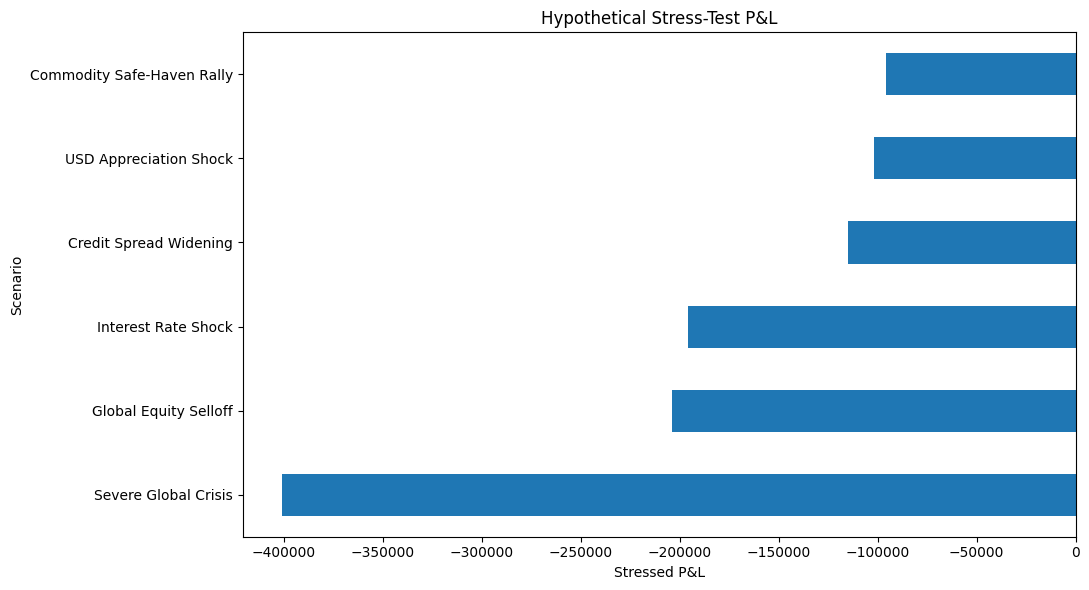

In [ ]:
stress_plot_data = (
    hypothetical_stress_results
    .set_index("scenario")[
        "stressed_pnl"
    ]
    .sort_values()
)

stress_plot_data.plot(
    kind="barh",
    figsize=(11, 6),
    title="Hypothetical Stress-Test P&L",
)

plt.xlabel("Stressed P&L")
plt.ylabel("Scenario")
plt.tight_layout()
plt.show()

### Contributions du pire scénario

In [ ]:
worst_scenario = (
    hypothetical_stress_results
    .iloc[0]["scenario"]
)

worst_scenario_contributions = (
    stress_asset_contributions[
        stress_asset_contributions[
            "scenario"
        ]
        == worst_scenario
    ]
    .sort_values(
        "pnl_contribution"
    )
)

print(
    "Worst hypothetical scenario:",
    worst_scenario,
)

worst_scenario_contributions

Worst hypothetical scenario: Severe Global Crisis


,scenario,asset,latest_weight,market_shock,return_contribution,pnl_contribution
6,Severe Global Crisis,US_EQUITY,0.250000,-0.350000,-0.087500,"-174,950.358050"
7,Severe Global Crisis,EUROPE_EQUITY,0.200000,-0.400000,-0.080000,"-159,954.613074"
9,Severe Global Crisis,CORPORATE_BOND,0.150000,-0.180000,-0.027000,"-53,984.681913"
11,Severe Global Crisis,EURUSD,0.100000,-0.100000,-0.010000,"-19,994.326634"
8,Severe Global Crisis,US_TREASURY,0.200000,-0.030000,-0.006000,"-11,996.595981"
10,Severe Global Crisis,GOLD,0.100000,0.100000,0.010000,"19,994.326634"


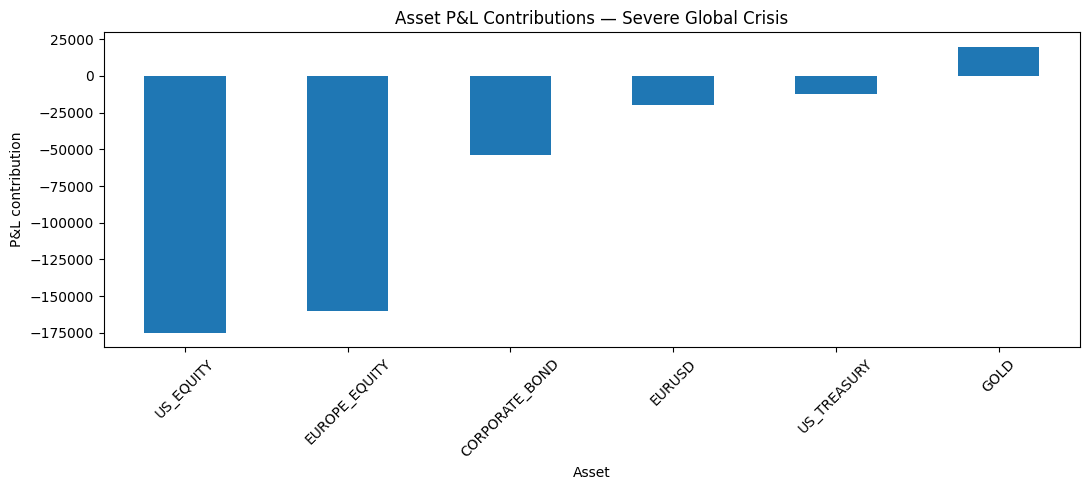

In [ ]:
worst_scenario_contributions.set_index(
    "asset"
)[
    "pnl_contribution"
].plot(
    kind="bar",
    figsize=(11, 5),
    title=(
        f"Asset P&L Contributions — "
        f"{worst_scenario}"
    ),
)

plt.xlabel("Asset")
plt.ylabel("P&L contribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Comparaison VaR et stress tests

### Récupérer la VaR statique

In [ ]:
static_var_99_comparison = (
    static_risk_metrics[
        static_risk_metrics[
            "confidence_level"
        ]
        == 0.99
    ]
    [
        [
            "model",
            "var_amount",
            "es_amount",
        ]
    ]
    .copy()
)

static_var_99_comparison

,model,var_amount,es_amount
10,Historical,"35,717.607647","52,141.525763"
11,Gaussian,"29,774.887392","34,208.695162"
12,Student-t,"34,621.196425","51,703.737037"
13,Monte Carlo Student-t,"34,442.076766","50,184.093055"
14,EWMA Gaussian,"29,900.817913",NaN


### Comparer à la pire perte stressée

In [ ]:
worst_hypothetical_loss = float(
    hypothetical_stress_results[
        "stress_loss"
    ].max()
)

worst_historical_daily_loss = float(
    -portfolio_daily_pnl.min()
)

risk_measure_comparison = (
    static_var_99_comparison.copy()
)

risk_measure_comparison[
    "worst_hypothetical_loss"
] = worst_hypothetical_loss

risk_measure_comparison[
    "worst_historical_daily_loss"
] = worst_historical_daily_loss

risk_measure_comparison[
    "hypothetical_loss_var_ratio"
] = (
    risk_measure_comparison[
        "worst_hypothetical_loss"
    ]
    / risk_measure_comparison[
        "var_amount"
    ]
)

risk_measure_comparison

,model,var_amount,es_amount,worst_hypothetical_loss,worst_historical_daily_loss,hypothetical_loss_var_ratio
10,Historical,"35,717.607647","52,141.525763","400,886.249018","58,860.168697",11.223771
11,Gaussian,"29,774.887392","34,208.695162","400,886.249018","58,860.168697",13.463905
12,Student-t,"34,621.196425","51,703.737037","400,886.249018","58,860.168697",11.579214
13,Monte Carlo Student-t,"34,442.076766","50,184.093055","400,886.249018","58,860.168697",11.639433
14,EWMA Gaussian,"29,900.817913",NaN,"400,886.249018","58,860.168697",13.407200


Cette comparaison montre pourquoi la VaR ne remplace pas les stress tests. La VaR représente une perte potentielle dans des conditions statistiques définies, alors que les stress tests examinent des scénarios extrêmes spécifiques.

## Validation des résultats de stress

### Contrôles finaux

In [ ]:
def validate_stress_test_outputs(
    historical_results: pd.DataFrame,
    hypothetical_results: pd.DataFrame,
    asset_contributions: pd.DataFrame,
) -> None:
    """Validate historical and hypothetical stress outputs."""

    if historical_results.empty:
        raise ValueError(
            "Historical stress results are empty."
        )

    if hypothetical_results.empty:
        raise ValueError(
            "Hypothetical stress results are empty."
        )

    if asset_contributions.empty:
        raise ValueError(
            "Stress asset contributions are empty."
        )

    required_hypothetical_columns = {
        "scenario",
        "portfolio_return",
        "stressed_pnl",
        "stress_loss",
        "initial_portfolio_value",
        "stressed_portfolio_value",
    }

    missing_columns = (
        required_hypothetical_columns
        - set(hypothetical_results.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing hypothetical stress columns: "
            f"{sorted(missing_columns)}"
        )

    if hypothetical_results[
        "initial_portfolio_value"
    ].le(0).any():
        raise ValueError(
            "Invalid initial portfolio values."
        )

    if hypothetical_results[
        "stressed_portfolio_value"
    ].le(0).any():
        raise ValueError(
            "A stress scenario produces "
            "a non-positive portfolio value."
        )

    expected_loss = (
        -hypothetical_results[
            "stressed_pnl"
        ]
    ).clip(lower=0)

    if not np.allclose(
        expected_loss,
        hypothetical_results[
            "stress_loss"
        ],
        atol=1e-8,
    ):
        raise ValueError(
            "Stress-loss convention is inconsistent."
        )

    print("Stress-test output validation successful.")


validate_stress_test_outputs(
    historical_results=
        historical_stress_results,
    hypothetical_results=
        hypothetical_stress_results,
    asset_contributions=
        stress_asset_contributions,
)

Stress-test output validation successful.


## Enregistrement des sorties

### Définir les fichiers

In [ ]:
NOTEBOOK_04_OUTPUTS = {
    "var_backtest_detailed_csv": (
        DATA_PROCESSED_DIR
        / "var_backtest_detailed.csv"
    ),

    "var_backtest_detailed_parquet": (
        DATA_PROCESSED_DIR
        / "var_backtest_detailed.parquet"
    ),

    "var_backtest_summary_csv": (
        REPORTS_DIR
        / "var_backtest_summary.csv"
    ),

    "statistical_backtest_results_csv": (
        REPORTS_DIR
        / "statistical_backtest_results.csv"
    ),

    "basel_traffic_light_csv": (
        REPORTS_DIR
        / "basel_traffic_light.csv"
    ),

    "var_exceptions_99_csv": (
        REPORTS_DIR
        / "var_exceptions_99.csv"
    ),

    "annual_exception_counts_csv": (
        REPORTS_DIR
        / "annual_exception_counts.csv"
    ),

    "historical_stress_results_csv": (
        REPORTS_DIR
        / "historical_stress_results.csv"
    ),

    "rolling_horizon_stress_results_csv": (
        REPORTS_DIR
        / "rolling_horizon_stress_results.csv"
    ),

    "hypothetical_stress_scenarios_csv": (
        CONFIG_DIR
        / "hypothetical_stress_scenarios.csv"
    ),

    "hypothetical_stress_results_csv": (
        REPORTS_DIR
        / "hypothetical_stress_results.csv"
    ),

    "hypothetical_stress_results_parquet": (
        DATA_PROCESSED_DIR
        / "hypothetical_stress_results.parquet"
    ),

    "stress_asset_contributions_csv": (
        REPORTS_DIR
        / "stress_asset_contributions.csv"
    ),

    "stress_asset_contributions_parquet": (
        DATA_PROCESSED_DIR
        / "stress_asset_contributions.parquet"
    ),

    "risk_measure_comparison_csv": (
        REPORTS_DIR
        / "risk_measure_comparison.csv"
    ),
}

## Sauvegarder les fichiers

In [ ]:
var_backtest_detailed.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "var_backtest_detailed_csv"
    ],
    index=False,
)

var_backtest_detailed.to_parquet(
    NOTEBOOK_04_OUTPUTS[
        "var_backtest_detailed_parquet"
    ],
    index=False,
)

var_backtest_summary.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "var_backtest_summary_csv"
    ],
    index=False,
)

statistical_backtest_results.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "statistical_backtest_results_csv"
    ],
    index=False,
)

# Calculate basel_traffic_light_results before saving it
basel_result_dict = (
    var_backtest_detailed[
        (
            var_backtest_detailed["confidence_level"] == 0.99
        )
        & (
            var_backtest_detailed["model"] == "Historical" # Assuming Historical model for Basel
        )
    ]["exception"]
    .pipe(basel_traffic_light)
)

basel_result_dict['model'] = 'Historical'
basel_result_dict['confidence_level'] = 0.99

basel_traffic_light_results = pd.DataFrame([basel_result_dict]) # Convert dict to DataFrame for .to_csv()

basel_traffic_light_results.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "basel_traffic_light_csv"
    ],
    index=False,
)

var_exceptions_99.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "var_exceptions_99_csv"
    ],
    index=False,
)

annual_exception_counts.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "annual_exception_counts_csv"
    ]
)

historical_stress_results.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "historical_stress_results_csv"
    ],
    index=False,
)

rolling_horizon_stress_results.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "rolling_horizon_stress_results_csv"
    ],
    index=False,
)

HYPOTHETICAL_STRESS_SCENARIOS.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "hypothetical_stress_scenarios_csv"
    ]
)

hypothetical_stress_results.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "hypothetical_stress_results_csv"
    ],
    index=False,
)

hypothetical_stress_results.to_parquet(
    NOTEBOOK_04_OUTPUTS[
        "hypothetical_stress_results_parquet"
    ],
    index=False,
)

stress_asset_contributions.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "stress_asset_contributions_csv"
    ],
    index=False,
)

stress_asset_contributions.to_parquet(
    NOTEBOOK_04_OUTPUTS[
        "stress_asset_contributions_parquet"
    ],
    index=False,
)

risk_measure_comparison.to_csv(
    NOTEBOOK_04_OUTPUTS[
        "risk_measure_comparison_csv"
    ],
    index=False,
)

print("Notebook 04 outputs saved successfully.")

Notebook 04 outputs saved successfully.


## Dépendances du notebook 5

### Définir les fichiers requis

In [ ]:
NOTEBOOK_05_DEPENDENCIES = [
    NOTEBOOK_04_OUTPUTS[
        "var_backtest_detailed_parquet"
    ],

    NOTEBOOK_04_OUTPUTS[
        "statistical_backtest_results_csv"
    ],

    NOTEBOOK_04_OUTPUTS[
        "basel_traffic_light_csv"
    ],

    NOTEBOOK_04_OUTPUTS[
        "historical_stress_results_csv"
    ],

    NOTEBOOK_04_OUTPUTS[
        "hypothetical_stress_results_parquet"
    ],

    NOTEBOOK_04_OUTPUTS[
        "stress_asset_contributions_parquet"
    ],

    NOTEBOOK_03_REQUIRED_FILES[
        "rolling_forecasts"
    ],

    NOTEBOOK_03_REQUIRED_FILES[
        "static_risk_metrics"
    ],

    NOTEBOOK_03_REQUIRED_FILES[
        "portfolio_timeseries"
    ],

    NOTEBOOK_03_REQUIRED_FILES[
        "portfolio_weights"
    ],
]

### Calculer les empreintes

In [ ]:
notebook_04_hashes = {
    file_path.name:
        calculate_file_hash(file_path)

    for file_path
    in NOTEBOOK_05_DEPENDENCIES
}

notebook_04_hashes

{'var_backtest_detailed.parquet': 'ab141d82012ebb342565401ad58d85417d932bbfb497187304e1f477c4b7560b',
 'statistical_backtest_results.csv': 'd4041c6b259944c199c2e7288c06cef4f1107def1fd080dd15a820ae536eb718',
 'basel_traffic_light.csv': '8a2bf54756197b07cf58c9cb9e7c754c438e41b0bec45e0bceda54359b77493d',
 'historical_stress_results.csv': '6f4478fb7d3ec91b64ef65c2e0ff99872e7a8e3a0e36b37b245ae067b9c72a6c',
 'hypothetical_stress_results.parquet': '16f26d51accfbf2ab910a1d4fc1173be80e84af9c5fc4324adde1f5a34264d84',
 'stress_asset_contributions.parquet': '6376f2364a4e5325128df6a2c00f44fa93ebde9e6f63b266aa0304a2b5dd3af2',
 'rolling_risk_forecasts.parquet': 'aa50c5589610db0f4635046115e0091297933278b5aec99df51cf5ed7bcf8213',
 'static_risk_metrics.parquet': 'c0411358656a2313f68a323a2948e2084c0a321eed326040d77d8fe7e71bca41',
 'portfolio_timeseries.parquet': '8ad5b57011be9abe8da80b2ac2a055acb3a344a7fd88ae806c42aa8252f2f5f1',
 'portfolio_weights.csv': '30770211096b759793962fb08d9985f0005e49940526f38bf

## Manifeste du notebook 4

### Créer le manifeste

In [ ]:
NOTEBOOK_04_MANIFEST_PATH = (
    CONFIG_DIR
    / "notebook_04_manifest.json"
)

generation_time = datetime.now(
    timezone.utc
).isoformat()

acceptable_model_count = int(
    (
        statistical_backtest_results[
            "overall_model_assessment"
        ]
        == "Acceptable"
    ).sum()
)

worst_historical_scenario = (
    historical_stress_results[
        historical_stress_results[
            "status"
        ]
        == "SUCCESS"
    ]
    .sort_values(
        "total_pnl"
    )
    .iloc[0]
)

worst_hypothetical_scenario = (
    hypothetical_stress_results
    .sort_values(
        "stressed_pnl"
    )
    .iloc[0]
)

notebook_04_manifest = {
    "pipeline_name":
        "Market Risk Analytics Platform",

    "pipeline_version":
        notebook_03_manifest[
            "pipeline_version"
        ],

    "producer_notebook":
        "04_backtesting_and_stress_testing.ipynb",

    "upstream_notebook":
        notebook_03_manifest[
            "producer_notebook"
        ],

    "upstream_manifest":
        str(
            NOTEBOOK_03_REQUIRED_FILES[
                "manifest"
            ]
            .relative_to(PROJECT_ROOT)
        ),

    "generated_at_utc":
        generation_time,

    "portfolio_name":
        notebook_03_manifest[
            "portfolio_name"
        ],

    "current_portfolio_value":
        current_portfolio_value,

    "backtested_models":
        list(
            BACKTEST_MODELS.keys()
        ),

    "backtested_confidence_levels": [
        0.95,
        0.99,
    ],

    "significance_level":
        SIGNIFICANCE_LEVEL,

    "backtest_observations":
        int(
            var_backtest_detailed[
                "date"
            ]
            .nunique()
        ),

    "acceptable_model_tests":
        acceptable_model_count,

    "total_model_tests":
        int(
            len(
                statistical_backtest_results
            )
        ),

    "worst_historical_scenario": {
        "scenario":
            worst_historical_scenario[
                "scenario"
            ],
        "total_pnl":
            float(
                worst_historical_scenario[
                    "total_pnl"
                ]
            ),
        "maximum_drawdown":
            float(
                worst_historical_scenario[
                    "maximum_drawdown"
                ]
            ),
    },

    "worst_hypothetical_scenario": {
        "scenario":
            worst_hypothetical_scenario[
                "scenario"
            ],
        "stressed_pnl":
            float(
                worst_hypothetical_scenario[
                    "stressed_pnl"
                ]
            ),
        "stress_loss":
            float(
                worst_hypothetical_scenario[
                    "stress_loss"
                ]
            ),
    },

    "hypothetical_scenario_count":
        int(
            len(
                hypothetical_stress_results
            )
        ),

    "historical_scenario_count":
        int(
            len(
                historical_stress_results
            )
        ),

    "notebook_05_dependencies": [
        str(
            file_path.relative_to(
                PROJECT_ROOT
            )
        )
        for file_path
        in NOTEBOOK_05_DEPENDENCIES
    ],

    "file_hashes":
        notebook_04_hashes,

    "status":
        "SUCCESS",
}

with open(
    NOTEBOOK_04_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        notebook_04_manifest,
        manifest_file,
        indent=4,
        ensure_ascii=False,
    )

print(
    "Notebook 04 manifest saved to:",
    NOTEBOOK_04_MANIFEST_PATH,
)

Notebook 04 manifest saved to: /content/drive/MyDrive/market-risk-analytics/config/notebook_04_manifest.json


## Validation des dépendances du notebook 5

### Validation finale

In [ ]:
def validate_notebook_04_outputs(
    required_files: list[Path],
    manifest_path: Path,
) -> None:
    """Validate all outputs required by Notebook 05."""

    missing_files = [
        file_path
        for file_path in required_files
        if not file_path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "Notebook 04 failed to create: "
            f"{missing_files}"
        )

    empty_files = [
        file_path
        for file_path in required_files
        if file_path.stat().st_size == 0
    ]

    if empty_files:
        raise ValueError(
            "Empty Notebook 04 outputs: "
            f"{empty_files}"
        )

    if not manifest_path.exists():
        raise FileNotFoundError(
            "Notebook 04 manifest "
            "was not created."
        )

    with open(
        manifest_path,
        "r",
        encoding="utf-8",
    ) as manifest_file:
        manifest = json.load(
            manifest_file
        )

    if manifest.get("status") != "SUCCESS":
        raise RuntimeError(
            "Notebook 04 manifest does "
            "not report SUCCESS."
        )

    if manifest.get("producer_notebook") != (
        "04_backtesting_and_stress_testing.ipynb"
    ):
        raise RuntimeError(
            "Unexpected producer notebook."
        )

    print(
        "All Notebook 04 dependencies are valid."
    )

    print(
        "Notebook 05 can now be executed."
    )


validate_notebook_04_outputs(
    required_files=NOTEBOOK_05_DEPENDENCIES,
    manifest_path=NOTEBOOK_04_MANIFEST_PATH,
)

All Notebook 04 dependencies are valid.
Notebook 05 can now be executed.


## Test de rechargement

### Simuler le notebook 5

In [ ]:
reloaded_backtest = pd.read_parquet(
    NOTEBOOK_04_OUTPUTS[
        "var_backtest_detailed_parquet"
    ]
)

reloaded_hypothetical_stress = (
    pd.read_parquet(
        NOTEBOOK_04_OUTPUTS[
            "hypothetical_stress_results_parquet"
        ]
    )
)

reloaded_stress_contributions = (
    pd.read_parquet(
        NOTEBOOK_04_OUTPUTS[
            "stress_asset_contributions_parquet"
        ]
    )
)

reloaded_statistical_tests = pd.read_csv(
    NOTEBOOK_04_OUTPUTS[
        "statistical_backtest_results_csv"
    ]
)

assert (
    reloaded_backtest.shape
    == var_backtest_detailed.shape
)

assert (
    reloaded_hypothetical_stress.shape
    == hypothetical_stress_results.shape
)

assert (
    reloaded_stress_contributions.shape
    == stress_asset_contributions.shape
)

assert (
    reloaded_statistical_tests.shape
    == statistical_backtest_results.shape
)

print("Notebook 05 loading test successful.")

print(
    "Backtesting observations:",
    reloaded_backtest.shape,
)

print(
    "Hypothetical stress scenarios:",
    reloaded_hypothetical_stress.shape,
)

print(
    "Stress contributions:",
    reloaded_stress_contributions.shape,
)

Notebook 05 loading test successful.
Backtesting observations: (12332, 11)
Hypothetical stress scenarios: (6, 6)
Stress contributions: (36, 6)


## Résumé final

### Tableau récapitulatif

In [ ]:
historical_99_summary = (
    var_backtest_summary[
        (
            var_backtest_summary[
                "model"
            ]
            == "Historical"
        )
        & (
            var_backtest_summary[
                "confidence_level"
            ]
            == 0.99
        )
    ]
    .iloc[0]
)

historical_99_tests = (
    statistical_backtest_results[
        (
            statistical_backtest_results[
                "model"
            ]
            == "Historical"
        )
        & (
            statistical_backtest_results[
                "confidence_level"
            ]
            == 0.99
        )
    ]
    .iloc[0]
)

historical_99_basel = (
    basel_traffic_light_results[
        basel_traffic_light_results[
            "model"
        ]
        == "Historical"
    ]
    .iloc[0]
)

notebook_04_summary = pd.DataFrame({
    "indicator": [
        "Pipeline status",
        "Current portfolio value",
        "Backtested models",
        "Confidence levels",
        "Historical VaR 99% observations",
        "Historical VaR 99% exceptions",
        "Historical VaR 99% exception rate",
        "Historical VaR 99% Kupiec result",
        "Historical VaR 99% independence result",
        "Historical VaR 99% conditional result",
        "Historical VaR 99% Basel zone",
        "Worst historical scenario",
        "Worst hypothetical scenario",
        "Worst hypothetical loss",
        "Files required by Notebook 05",
    ],

    "value": [
        "SUCCESS",
        current_portfolio_value,
        len(BACKTEST_MODELS),
        "95% and 99%",
        historical_99_summary[
            "number_of_observations"
        ],
        historical_99_summary[
            "number_of_exceptions"
        ],
        historical_99_summary[
            "observed_exception_rate"
        ],
        historical_99_tests[
            "kupiec_result"
        ],
        historical_99_tests[
            "independence_result"
        ],
        historical_99_tests[
            "conditional_coverage_result"
        ],
        historical_99_basel[
            "traffic_light_zone"
        ],
        worst_historical_scenario[
            "scenario"
        ],
        worst_hypothetical_scenario[
            "scenario"
        ],
        worst_hypothetical_scenario[
            "stress_loss"
        ],
        len(NOTEBOOK_05_DEPENDENCIES),
    ],
})

notebook_04_summary

,indicator,value
0,Pipeline status,SUCCESS
1,Current portfolio value,"1,999,432.663429"
2,Backtested models,3
3,Confidence levels,95% and 99%
4,Historical VaR 99% observations,1982
5,Historical VaR 99% exceptions,34
6,Historical VaR 99% exception rate,0.017154
7,Historical VaR 99% Kupiec result,Reject
8,Historical VaR 99% independence result,Reject
9,Historical VaR 99% conditional result,Reject


## Conclusion du notebook

## Conclusion

Notebook 04 successfully evaluated the reliability of the rolling VaR forecasts and assessed the portfolio's resilience under extreme market conditions.

### Backtesting results

The following models were backtested at 95% and 99% confidence levels:

- Historical VaR;
- Gaussian Parametric VaR;
- EWMA Gaussian VaR.

For each model, the analysis included:

- observed number of VaR exceptions;
- expected number of exceptions;
- exception rate;
- average and maximum VaR;
- magnitude of VaR exceedances;
- Kupiec unconditional coverage test;
- Christoffersen independence test;
- conditional coverage test;
- Basel traffic-light classification at 99%.

### Stress-testing results

The portfolio was assessed using:

- historical crisis periods;
- worst observed losses over 1, 5, 10 and 20 trading days;
- hypothetical equity-market shocks;
- interest-rate shocks;
- credit-spread widening;
- foreign-exchange shocks;
- severe global-crisis scenarios;
- safe-haven commodity scenarios.

Asset-level contributions were calculated for every hypothetical scenario.

### Main interpretation principles

- A model may have the correct number of exceptions but still fail if the exceptions are clustered.
- The Kupiec test evaluates exception frequency.
- The Christoffersen independence test evaluates exception clustering.
- The conditional coverage test evaluates both properties simultaneously.
- VaR measures potential loss under a statistical confidence level.
- Stress tests assess losses under explicit extreme scenarios.
- VaR and stress testing are complementary and should not be interpreted as substitutes.

### Main limitations

- Hypothetical stress tests use a linear shock approximation.
- The shocks are applied directly to the selected market proxies.
- Nonlinear instruments and option Greeks are excluded.
- Liquidity costs and market impact are excluded.
- Correlation changes are embedded manually through the joint scenario shocks.
- Historical stress periods depend on the available sample.
- The Basel traffic-light interpretation is most meaningful with a complete 250-day sample.

### Dependency created for Notebook 05

Notebook 05 must load and validate:

- `data/processed/var_backtest_detailed.parquet`;
- `reports/statistical_backtest_results.csv`;
- `reports/basel_traffic_light.csv`;
- `reports/historical_stress_results.csv`;
- `data/processed/hypothetical_stress_results.parquet`;
- `data/processed/stress_asset_contributions.parquet`;
- `data/processed/rolling_risk_forecasts.parquet`;
- `data/processed/static_risk_metrics.parquet`;
- `data/processed/portfolio_timeseries.parquet`;
- `data/processed/actual_portfolio_weights.parquet`;
- `config/notebook_04_manifest.json`.

### Next step

Notebook 05 will perform:

- portfolio risk-factor analysis;
- rolling correlation analysis;
- volatility contribution;
- marginal and component VaR;
- concentration analysis;
- Principal Component Analysis;
- consolidation of portfolio, VaR, backtesting and stress-test results;
- generation of the final automated risk report.